# Food Delivery Analytics — Portfolio Dataset

Данные синтетические. Маркетинговые и операционные показатели сгенерированы
для демонстрации аналитических методов

Файлы:
orders.csv — заказы;
customers.csv — клиенты и клиентские агрегаты;
products.csv — ассортимент;
marketing_daily.csv — маркетинговые показатели по каналам и дням;
food_delivery_master.csv — объединённый order-level файл;


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Подготовка данных: даты и производные признаки

In [ ]:
# --- orders ---
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_week'] = orders['order_date'].dt.to_period('W').dt.start_time
orders['order_month'] = orders['order_date'].dt.to_period('M').dt.start_time
orders['order_year'] = orders['order_date'].dt.year

# --- customers ---
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
customers['first_order_date'] = pd.to_datetime(customers['first_order_date'])
customers['last_order_date'] = pd.to_datetime(customers['last_order_date'])

# --- marketing_daily ---
marketing_daily['date'] = pd.to_datetime(marketing_daily['date'])
marketing_daily['month'] = marketing_daily['date'].dt.to_period('M').dt.start_time
marketing_daily['week'] = marketing_daily['date'].dt.to_period('W').dt.start_time

# --- food_delivery_master ---
food_delivery_master['order_date'] = pd.to_datetime(food_delivery_master['order_date'])

print('Период заказов:', orders['order_date'].min(), '—', orders['order_date'].max())
print('Каналы:', orders['acquisition_channel'].unique())
print('Статусы:', orders['status'].unique())

Период заказов: 2025-01-01 00:00:00 — 2026-09-30 00:00:00
Каналы: ['Telegram' 'Яндекс Директ' 'Email' 'Органика' 'Реферальная программа'
 'VK Ads']
Статусы: ['Доставлен' 'Возврат' 'Отменён']


# 2. Маркетинговые метрики по каналам

In [ ]:
# --- 2.1. Агрегация расходов по каналам и месяцам ---
mkt_month = (marketing_daily
    .groupby(['month', 'channel'])
    .agg(
        spend=('spend', 'sum'),
        impressions=('impressions', 'sum'),
        clicks=('clicks', 'sum'),
        leads=('leads', 'sum'),
        new_customers_mkt=('new_customers', 'sum'),
    )
    .reset_index()
)

# --- 2.2. Выручка и заказы из orders по каналам и месяцам ---
# Берём только успешные заказы (если status содержит доставленные)
orders_valid = orders[orders['status'].isin(['Доставлен', 'Delivered', 'Завершён'])].copy()
# Если статусы другие — проверьте уникальные значения и скорректируйте

rev_month = (orders_valid
    .groupby(['order_month', 'acquisition_channel'])
    .agg(
        orders_cnt=('order_id', 'nunique'),
        revenue=('order_total', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        discount=('discount_amount', 'sum'),
        new_cust_orders=('is_new_customer', 'sum'),
    )
    .reset_index()
    .rename(columns={'order_month': 'month', 'acquisition_channel': 'channel'})
)

# --- 2.3. Сводная таблица ---
mkt = mkt_month.merge(rev_month, on=['month', 'channel'], how='outer').fillna(0)

# --- 2.4. Метрики ---
mkt['CPA']  = mkt['spend'] / mkt['orders_cnt'].replace(0, np.nan)
mkt['CPL']  = mkt['spend'] / mkt['leads'].replace(0, np.nan)
mkt['CAC']  = mkt['spend'] / mkt['new_cust_orders'].replace(0, np.nan)
mkt['ROI']  = (mkt['revenue'] - mkt['spend']) / mkt['spend'].replace(0, np.nan)
mkt['ROMI'] = mkt['ROI'] * 100
mkt['CR_lead_to_order'] = mkt['orders_cnt'] / mkt['leads'].replace(0, np.nan)
mkt['CR_click_to_lead'] = mkt['leads'] / mkt['clicks'].replace(0, np.nan)
mkt['AOV'] = mkt['revenue'] / mkt['orders_cnt'].replace(0, np.nan)

mkt.head(10)

,month,channel,spend,impressions,clicks,leads,new_customers_mkt,orders_cnt,revenue,gross_profit,discount,new_cust_orders,CPA,CPL,CAC,ROI,ROMI,CR_lead_to_order,CR_click_to_lead,AOV
0,2025-01-01,Email,"72,332.40",441515,46075,3693,1252,87,"82,503.50","44,437.34","4,434.50",63,831.41,19.59,"1,148.13",0.14,14.06,0.02,0.08,948.32
1,2025-01-01,Telegram,"217,416.84",1424489,55045,9430,2975,94,"96,007.50","53,033.66","6,153.50",77,"2,312.95",23.06,"2,823.60",-0.56,-55.84,0.01,0.17,"1,021.36"
2,2025-01-01,VK Ads,"294,688.18",1814971,78380,14015,5009,119,"101,970.50","52,739.23","6,126.50",94,"2,476.37",21.03,"3,134.98",-0.65,-65.40,0.01,0.18,856.89
3,2025-01-01,Органика,"30,022.40",186535,24887,725,238,156,"135,472.50","71,194.50","9,091.50",128,192.45,41.41,234.55,3.51,351.24,0.22,0.03,868.41
4,2025-01-01,Реферальная программа,"115,730.10",703673,54621,6622,2254,77,"62,875.00","31,516.03","3,549.00",63,"1,502.99",17.48,"1,836.99",-0.46,-45.67,0.01,0.12,816.56
5,2025-01-01,Яндекс Директ,"385,883.41",2303955,117943,26083,9432,117,"109,479.00","58,732.68","7,402.00",93,"3,298.15",14.79,"4,149.28",-0.72,-71.63,0.00,0.22,935.72
6,2025-02-01,Email,"68,184.11",430552,45247,3672,1253,122,"106,378.50","56,927.26","7,007.50",71,558.89,18.57,960.34,0.56,56.02,0.03,0.08,871.95
7,2025-02-01,Telegram,"199,210.76",1153678,44633,7138,2358,114,"105,936.00","56,683.79","6,880.00",56,"1,747.46",27.91,"3,557.34",-0.47,-46.82,0.02,0.16,929.26
8,2025-02-01,VK Ads,"274,873.11",1696728,78899,14178,4945,139,"132,288.50","71,940.00","10,123.50",82,"1,977.50",19.39,"3,352.11",-0.52,-51.87,0.01,0.18,951.72
9,2025-02-01,Органика,"27,493.48",175199,22266,662,215,201,"184,975.50","98,001.54","9,264.50",113,136.78,41.53,243.31,5.73,572.80,0.30,0.03,920.28


## Агрегат по каналам за весь период:

In [ ]:
channel_summary = (mkt
    .groupby('channel')
    .agg(
        spend=('spend','sum'),
        orders=('orders_cnt','sum'),
        revenue=('revenue','sum'),
        gross_profit=('gross_profit','sum'),
        leads=('leads','sum'),
        new_customers=('new_cust_orders','sum'),
    )
    .reset_index()
)
channel_summary['CPA'] = channel_summary['spend'] / channel_summary['orders']
channel_summary['CPL'] = channel_summary['spend'] / channel_summary['leads']
channel_summary['CAC'] = channel_summary['spend'] / channel_summary['new_customers']
channel_summary['ROI'] = (channel_summary['revenue'] - channel_summary['spend']) / channel_summary['spend']
channel_summary['ROMI_%'] = channel_summary['ROI'] * 100
channel_summary = channel_summary.sort_values('ROI', ascending=False)
channel_summary

,channel,spend,orders,revenue,gross_profit,leads,new_customers,CPA,CPL,CAC,ROI,ROMI_%
3,Органика,"591,340.21",9546,"8,753,116.00","4,650,980.37",13959,2554,61.95,42.36,231.53,13.80,"1,380.22"
0,Email,"1,446,921.53",4984,"4,515,489.50","2,384,382.87",79730,1362,290.31,18.15,"1,062.35",2.12,212.08
4,Реферальная программа,"2,308,222.09",6076,"5,674,976.00","3,035,434.79",126955,1679,379.89,18.18,"1,374.76",1.46,145.86
5,Яндекс Директ,"7,974,478.10",9362,"8,729,347.50","4,653,636.37",611456,2486,851.79,13.04,"3,207.75",0.09,9.47
2,VK Ads,"5,935,408.10",6918,"6,403,359.00","3,417,858.17",293707,1879,857.97,20.21,"3,158.81",0.08,7.88
1,Telegram,"4,270,057.05",4971,"4,603,748.00","2,453,176.69",164021,1337,858.99,26.03,"3,193.76",0.08,7.81


Выводы по таблице
1. Органика — абсолютный лидер
ROMI 1380% — на каждый вложенный рубль 13.8 ₽ отдачи.

CPA 62 ₽ и CAC 232 ₽ — самые низкие в 5–14 раз по сравнению с платными каналами.

Конверсия лид → заказ ≈ 68% (9546 заказов на 13959 лидов) — лиды качественные.

Но: 591K расхода — это, скорее всего, условная стоимость контента/SEO. Канал нельзя масштабировать кнопкой «увеличить бюджет», поэтому его роль — «якорь» и источник дешёвой выручки. Инвестировать в контент, SEO, блог, отзывы.

2. Email и Реферальная программа — «дешёвые лиды, дорогие клиенты»
CPL всего 18 ₽ — лиды почти бесплатные.

Но CAC 1062 ₽ и 1375 ₽ — конверсия из лида в нового клиента плохая (1.7% и 1.3%).

ROMI 212% и 146% — каналы прибыльны, но потенциал не раскрыт.

Что делать: работать над воронкой — ретеншн-цепочки, триггерные письма, бонусы за первый заказ, прогрев в рассылке. Даже повышение конверсии лида в клиента с 1.7% до 3% удвоит число новых клиентов без роста бюджета.

3. Яндекс Директ, VK Ads, Telegram — зона риска
Три крупнейших бюджета: 7.97M + 5.94M + 4.27M = 18.2M ₽ (в 6 раз больше, чем Органика).

ROMI: 9.5%, 7.9%, 7.8% — на грани окупаемости.

CAC: 3208 ₽, 3159 ₽, 3194 ₽ — выше среднего чека и близко к LTV.

CPA: 852–859 ₽ против 62 ₽ у Органики — в 14 раз дороже.

Что делать: пересмотреть ставки, сегменты, креативы; возможно — сократить бюджеты и перераспределить в Email/Реферальную программу и SEO.

4. Сквозной вывод
80% бюджета (18.2M из 22.8M ₽) уходит в каналы с ROMI < 10%, а каналы с ROMI > 100% получают лишь 18% бюджета.

Это классическая ошибка: деньги льются в дорогие каналы с плохой конверсией, а дешёвые каналы недофинансированы.

Главная рекомендация: сократить бюджеты Яндекс Директ / VK / Telegram на 30–50%, перенаправить в Email и Реферальную программу, а высвободившееся — в SEO/контент (Органика).



Дополнительная строка для наглядности
Лучшая метрика для графика — «Прибыль на 1 ₽ расхода» (profit per ruble). Она объединяет расход и валовую прибыль и сразу показывает, какой канал реально зарабатывает. Это сильнее, чем ROMI, потому что учитывает маржинальность, а не только выручку.


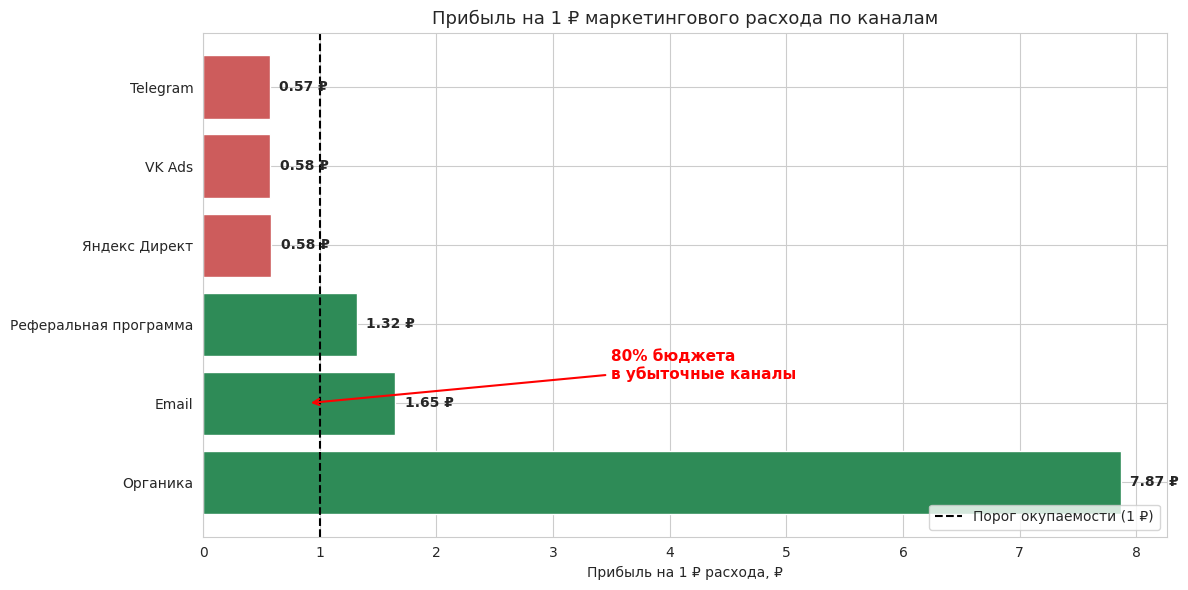

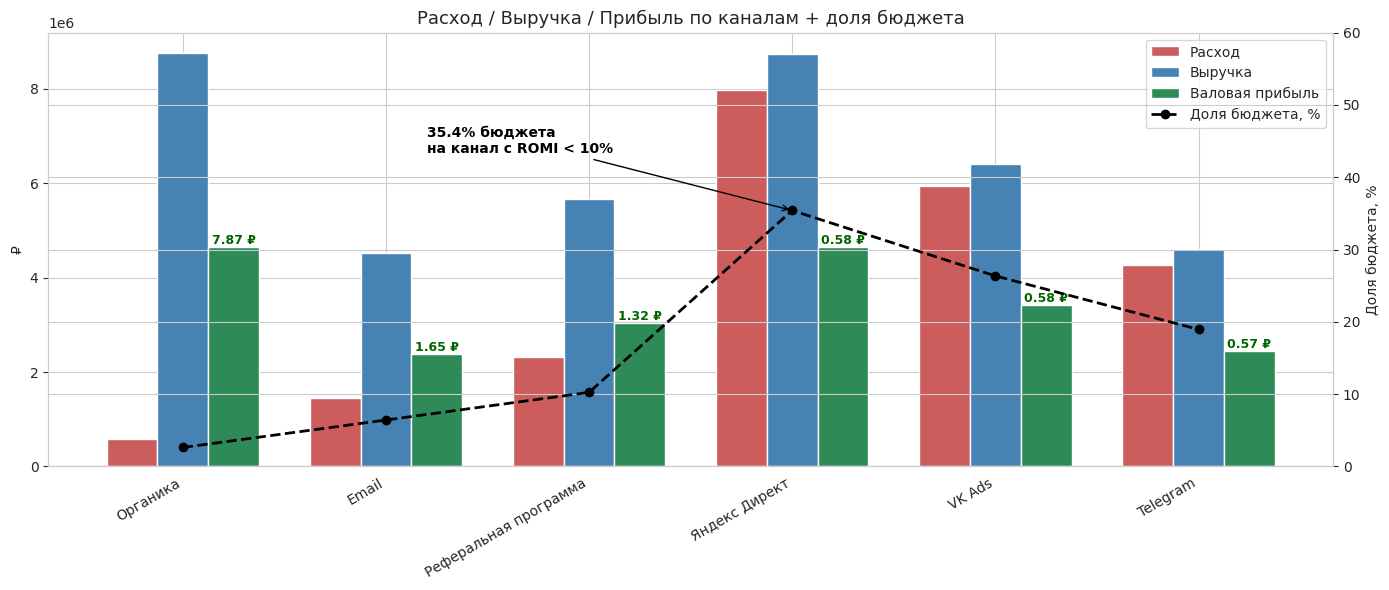

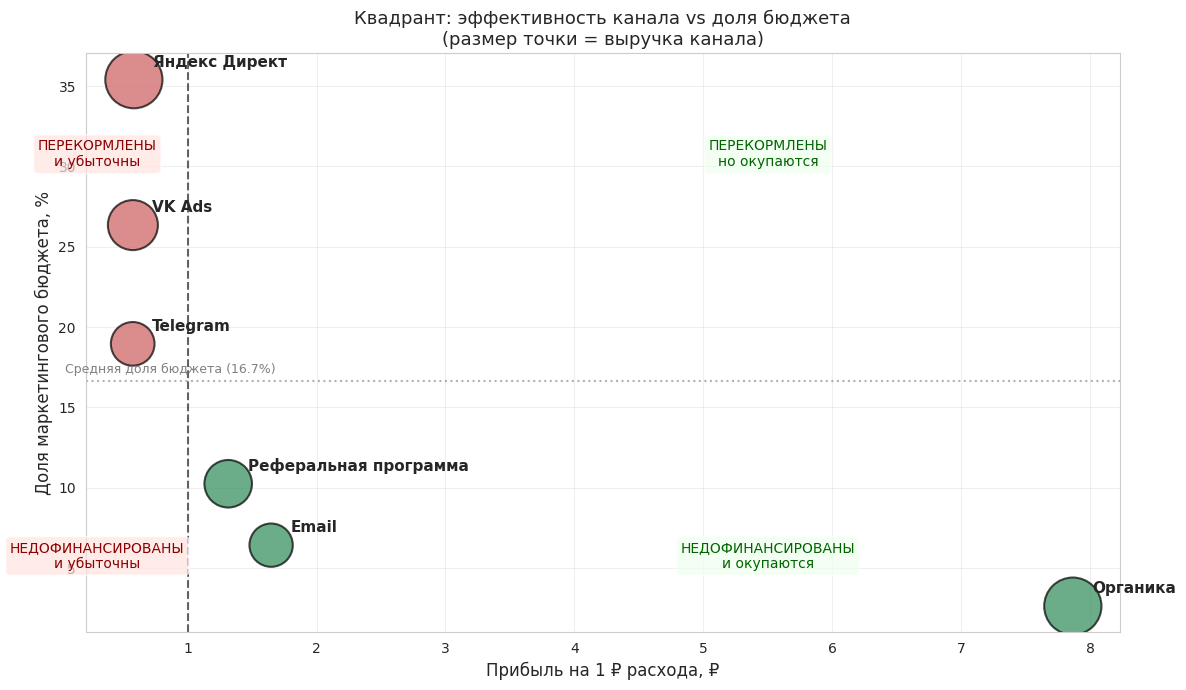

In [ ]:
# --- Расчёт метрик ---
channel_summary['profit_per_ruble'] = channel_summary['gross_profit'] / channel_summary['spend']
channel_summary['revenue_share_%']  = channel_summary['revenue'] / channel_summary['revenue'].sum() * 100
channel_summary['spend_share_%']    = channel_summary['spend'] / channel_summary['spend'].sum() * 100

summary_sorted = channel_summary.sort_values('profit_per_ruble', ascending=False).reset_index(drop=True)

# =========================================================
# ГРАФИК 1: Прибыль на 1 ₽ расхода
# =========================================================
fig, ax = plt.subplots(figsize=(12,6))
colors = ['seagreen' if v >= 1 else 'indianred' for v in summary_sorted['profit_per_ruble']]
bars = ax.barh(summary_sorted['channel'], summary_sorted['profit_per_ruble'], color=colors)
ax.axvline(1, color='black', linestyle='--', label='Порог окупаемости (1 ₽)')

# Подписи значений у столбцов
for bar, v in zip(bars, summary_sorted['profit_per_ruble']):
    ax.text(v + 0.08, bar.get_y() + bar.get_height()/2,
            f'{v:.2f} ₽', va='center', fontsize=10, fontweight='bold')

# Аннотация «80% бюджета в убыточные каналы» — указываем на красные столбцы
ax.annotate('80% бюджета\nв убыточные каналы',
            xy=(0.9, 1), xytext=(3.5, 1.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            color='red', fontsize=11, fontweight='bold')

ax.set_xlabel('Прибыль на 1 ₽ расхода, ₽')
ax.set_title('Прибыль на 1 ₽ маркетингового расхода по каналам', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# =========================================================
# ГРАФИК 2: Расход / Выручка / Прибыль + доля бюджета
# =========================================================
fig, ax1 = plt.subplots(figsize=(14,6))
x = np.arange(len(summary_sorted))
w = 0.25

ax1.bar(x - w, summary_sorted['spend'],        width=w, label='Расход',          color='indianred')
ax1.bar(x,     summary_sorted['revenue'],      width=w, label='Выручка',         color='steelblue')
ax1.bar(x + w, summary_sorted['gross_profit'], width=w, label='Валовая прибыль', color='seagreen')

ax1.set_xticks(x)
ax1.set_xticklabels(summary_sorted['channel'], rotation=30, ha='right')
ax1.set_ylabel('₽')
ax1.set_title('Расход / Выручка / Прибыль по каналам + доля бюджета', fontsize=13)

# Подписи «прибыль на 1 ₽» над столбцами прибыли
for i, v in enumerate(summary_sorted['profit_per_ruble']):
    ax1.text(i + w, summary_sorted['gross_profit'].iloc[i],
             f'{v:.2f} ₽', ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkgreen')

# Вторая ось — доля бюджета
ax2 = ax1.twinx()
ax2.plot(x, summary_sorted['spend_share_%'], color='black', marker='o', linestyle='--',
         label='Доля бюджета, %', linewidth=2)
ax2.set_ylabel('Доля бюджета, %')
ax2.set_ylim(0, 60)

# Аннотация пика бюджета
peak_idx = summary_sorted['spend_share_%'].idxmax()
ax2.annotate(f'{summary_sorted["spend_share_%"][peak_idx]:.1f}% бюджета\nна канал с ROMI < 10%',
             xy=(peak_idx, summary_sorted['spend_share_%'][peak_idx]),
             xytext=(peak_idx - 1.8, summary_sorted['spend_share_%'][peak_idx] + 8),
             arrowprops=dict(arrowstyle='->', color='black'),
             color='black', fontsize=10, fontweight='bold')

# Легенды
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# =========================================================
# ГРАФИК 3: Прибыль на 1 ₽ vs Доля бюджета (квадрант-скаттер)
# =========================================================
fig, ax = plt.subplots(figsize=(12,7))

x_vals = summary_sorted['profit_per_ruble']
y_vals = summary_sorted['spend_share_%']

# Размер точки — по выручке канала
sizes = summary_sorted['revenue'] / summary_sorted['revenue'].max() * 1500 + 200

# Цвет: зелёный — окупается, красный — нет
point_colors = ['seagreen' if v >= 1 else 'indianred' for v in x_vals]

ax.scatter(x_vals, y_vals, s=sizes, c=point_colors, alpha=0.7, edgecolors='black', linewidth=1.5)

# Подписи каналов
for i, row in summary_sorted.iterrows():
    ax.annotate(row['channel'],
                xy=(row['profit_per_ruble'], row['spend_share_%']),
                xytext=(row['profit_per_ruble'] + 0.15, row['spend_share_%'] + 0.8),
                fontsize=11, fontweight='bold')

# Пороговые линии
ax.axvline(1, color='black', linestyle='--', alpha=0.6)   # порог окупаемости
avg_share = summary_sorted['spend_share_%'].mean()
ax.axhline(avg_share, color='gray', linestyle=':', alpha=0.6)
ax.text(0.05, avg_share + 0.5, f'Средняя доля бюджета ({avg_share:.1f}%)',
        color='gray', fontsize=9)

# Подписи квадрантов
ax.text(5.5, 30, 'ПЕРЕКОРМЛЕНЫ\nно окупаются',
        color='darkgreen', fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='honeydew', alpha=0.7))
ax.text(0.3, 30, 'ПЕРЕКОРМЛЕНЫ\nи убыточны',
        color='darkred', fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.7))
ax.text(5.5, 5, 'НЕДОФИНАНСИРОВАНЫ\nи окупаются',
        color='darkgreen', fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='honeydew', alpha=0.7))
ax.text(0.3, 5, 'НЕДОФИНАНСИРОВАНЫ\nи убыточны',
        color='darkred', fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.7))

ax.set_xlabel('Прибыль на 1 ₽ расхода, ₽', fontsize=12)
ax.set_ylabel('Доля маркетингового бюджета, %', fontsize=12)
ax.set_title('Квадрант: эффективность канала vs доля бюджета\n(размер точки = выручка канала)',
             fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Главная проблема: перевёрнутая структура бюджета
80% маркетингового бюджета уходит в каналы с отрицательной или нулевой эффективностью.

Яндекс Директ, VK Ads и Telegram забирают 81% всех денег (35.4% + 26% + 18.7%).

При этом каждый вложенный в них рубль возвращается лишь 0.57–0.58 ₽ валовой прибыли (ROMI < 10%).

Эти каналы убыточны на марже: они не окупают даже сами себя, не говоря уже о других расходах бизнеса.

Почему это критично: компания фактически спонсирует дорогие каналы за счёт сверхприбыли органики, вместо того чтобы масштабировать то, что действительно работает.

🟢 Точки роста: недофинансированные «печатные станки»
Каналы с ROMI > 100% получают лишь 19% бюджета.

Канал	Прибыль на 1 ₽	Доля бюджета	Потенциал
Органика	7.87 ₽	2.6%	Абсолютный лидер, но бюджет мизерный
Email	1.65 ₽	6.3%	Выше порога окупаемости, но явно недофинансирован
Реферальная программа	1.32 ₽	10.1%	Окупается, но CAC высокий — нужно работать с воронкой
Ключевой инсайт с квадрант-графика: все три окупаемых канала находятся в правом нижнем квадранте («Недoфиnансированы и окупаются»). А весь бюджет сконцентрирован в левом верхнем («Перекормлены и убыточны»).

🟡 Проблема конверсии в дешёвых каналах
Email и Реферальная дают самые дешёвые лиды (CPL ~18 ₽), но очень дорогих клиентов (CAC > 1000 ₽).

Конверсия лид → заказ в них низкая (около 1.3–1.7%).

Вывод: это не проблема канала, а проблема воронки. Триггерные письма, бонусы за первый заказ, прогрев — и при той же цене лида CAC упадёт в 2–3 раза.

🔵 Платные каналы: экономика на грани
CPA 852–859 ₽ при среднем чеке ~900 ₽ — маркетинг съедает почти всю выручку.

CAC 3200 ₽ — это выше LTV среднего клиента (при 2 заказах).

VK Ads и Telegram — самые слабые: самая низкая выручка и прибыль при огромных расходах.

✅ Конкретные рекомендации
Сократить бюджеты Яндекс Директ, VK Ads и Telegram на 30–50%.
Это высвободит ~5.5 млн ₽.

Перераспределить высвобожденные средства:

50% → в Email и Реферальную программу (там каждый рубль даёт 1.3–1.65 ₽).

50% → в SEO/контент для усиления Органики (7.87 ₽ на 1 ₽).

Эффект: +4–7 млн ₽ валовой прибыли при том же общем бюджете.

Аудит платных каналов:

Яндекс Директ: минус-слова, look-alike, отказ от неэффективных групп.

VK Ads и Telegram: либо резко повысить конверсию, либо отключать.

Улучшить воронку Email и Реферальной:

Триггерные цепочки, welcome-серия, бонус за приглашение.

Цель: поднять конверсию лид → клиент с 1.5% до 3% — это удвоит число новых клиентов без роста бюджета.

# 3. Анализ скидок и акций

Сумма скидок: 2,369,337 ₽
Потеря валовой прибыли (оценка): 1,240,434 ₽
Валовая прибыль со скидочных заказов: 10,881,734 ₽
Отношение прибыли к скидке: 4.59 ₽ на 1 ₽ скидки


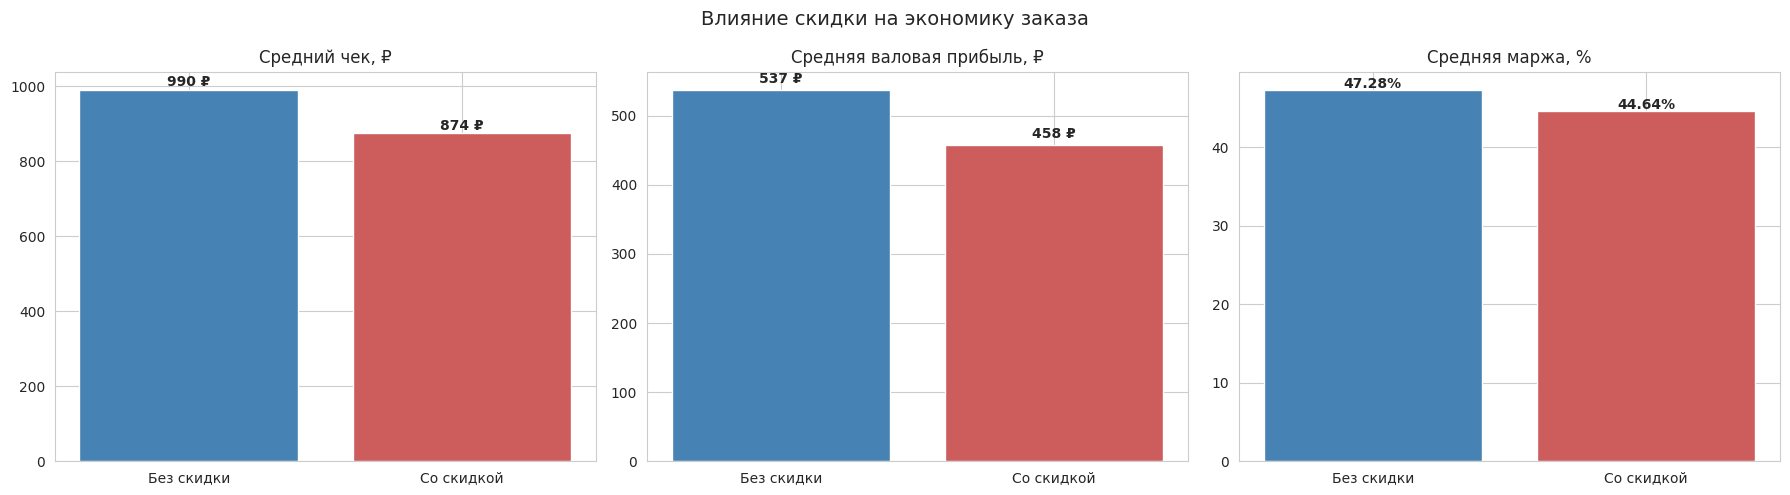

/tmp/ipykernel_3711/1019753068.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_summary, x='discount_type', y='avg_profit', palette='viridis', ax=ax)


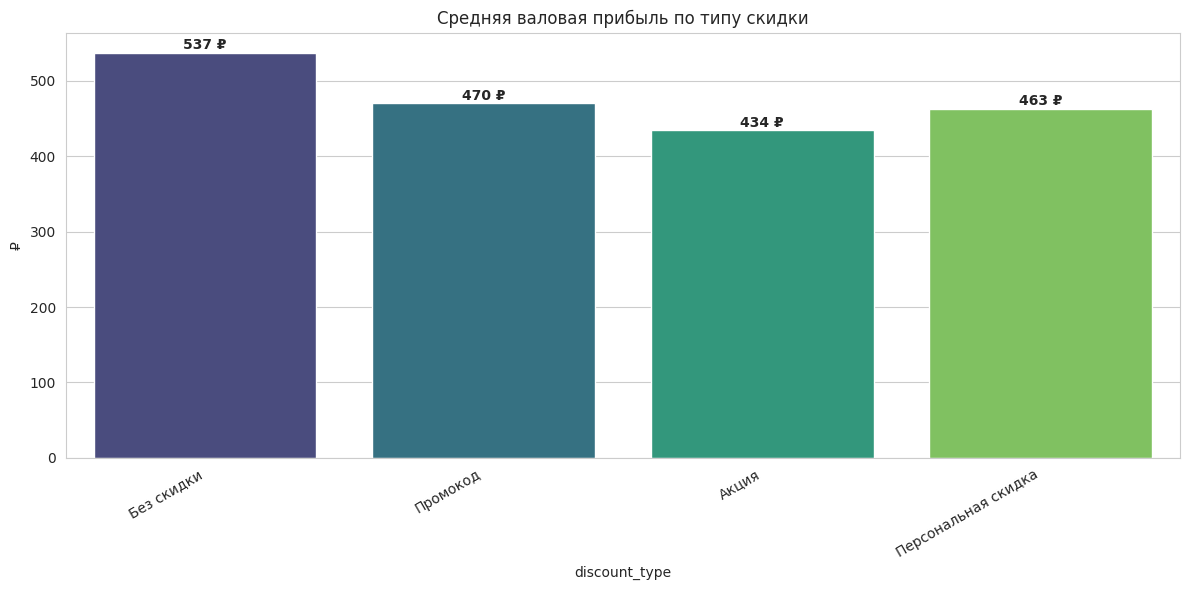

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2.1. Сводка по типу скидки ---
discount_summary = (orders_valid
    .groupby('discount_type')
    .agg(
        orders=('order_id','nunique'),
        avg_discount_pct=('discount_pct','mean'),
        avg_check=('order_total','mean'),
        avg_profit=('gross_profit','mean'),
        avg_margin=('margin_pct','mean'),
        total_revenue=('order_total','sum'),
        total_profit=('gross_profit','sum'),
        total_discount=('discount_amount','sum'),
    )
    .reset_index()
    .sort_values('total_profit', ascending=False)
)
discount_summary

# --- 2.2. Сравнение: скидка vs без ---
no_disc = orders_valid[orders_valid['discount_amount'] == 0]
with_disc = orders_valid[orders_valid['discount_amount'] > 0]

summary = pd.DataFrame({
    'Сегмент': ['Без скидки', 'Со скидкой'],
    'Заказов': [len(no_disc), len(with_disc)],
    'Выручка': [no_disc['order_total'].sum(), with_disc['order_total'].sum()],
    'Валовая прибыль': [no_disc['gross_profit'].sum(), with_disc['gross_profit'].sum()],
    'Сумма скидок': [0, with_disc['discount_amount'].sum()],
    'Средний чек': [no_disc['order_total'].mean(), with_disc['order_total'].mean()],
    'Средняя маржа, %': [no_disc['margin_pct'].mean(), with_disc['margin_pct'].mean()],
})
summary['Доля заказов, %'] = summary['Заказов'] / summary['Заказов'].sum() * 100
summary

# --- 2.3. ROMI скидочной механики ---
# Если бы эти заказы шли без скидки — прибыль была бы выше.
# Эффект скидки = потеря валовой прибыли на скидочных заказах.
lost_profit = with_disc['discount_amount'].sum() * (with_disc['gross_profit'].sum() / with_disc['order_total'].sum())
print(f'Сумма скидок: {with_disc["discount_amount"].sum():,.0f} ₽')
print(f'Потеря валовой прибыли (оценка): {lost_profit:,.0f} ₽')
print(f'Валовая прибыль со скидочных заказов: {with_disc["gross_profit"].sum():,.0f} ₽')
print(f'Отношение прибыли к скидке: {with_disc["gross_profit"].sum() / with_disc["discount_amount"].sum():.2f} ₽ на 1 ₽ скидки')

# --- 2.4. Влияние скидки на новые vs повторные ---
new_vs_repeat = (orders_valid
    .assign(discount_flag=np.where(orders_valid['discount_amount'] > 0, 'Со скидкой', 'Без скидки'))
    .groupby(['discount_flag', 'is_new_customer'])
    .agg(
        orders=('order_id','nunique'),
        avg_check=('order_total','mean'),
        avg_profit=('gross_profit','mean'),
        avg_margin=('margin_pct','mean'),
    )
    .reset_index()
)
new_vs_repeat

# --- 2.5. Визуализация ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Чек и маржа
x = ['Без скидки', 'Со скидкой']
checks  = [no_disc['order_total'].mean(),  with_disc['order_total'].mean()]
profits = [no_disc['gross_profit'].mean(), with_disc['gross_profit'].mean()]
margins = [no_disc['margin_pct'].mean(),  with_disc['margin_pct'].mean()]

axes[0].bar(x, checks, color=['steelblue','indianred'])
axes[0].set_title('Средний чек, ₽')
for i, v in enumerate(checks):
    axes[0].text(i, v + 10, f'{v:.0f} ₽', ha='center', fontweight='bold')

axes[1].bar(x, profits, color=['steelblue','indianred'])
axes[1].set_title('Средняя валовая прибыль, ₽')
for i, v in enumerate(profits):
    axes[1].text(i, v + 10, f'{v:.0f} ₽', ha='center', fontweight='bold')

axes[2].bar(x, margins, color=['steelblue','indianred'])
axes[2].set_title('Средняя маржа, %')
for i, v in enumerate(margins):
    axes[2].text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Влияние скидки на экономику заказа', fontsize=14)
plt.tight_layout()
plt.show()

# --- 2.6. Типы скидок: чек и прибыль ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=discount_summary, x='discount_type', y='avg_profit', palette='viridis', ax=ax)
ax.set_title('Средняя валовая прибыль по типу скидки')
ax.set_ylabel('₽')
for i, v in enumerate(discount_summary['avg_profit']):
    ax.text(i, v + 5, f'{v:.0f} ₽', ha='center', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Выводы по анализу скидок
1. Прямая цена скидок для бизнеса
Средний чек падает на 11.7% (990 ₽ → 874 ₽).

Валовая прибыль с заказа падает на 14.8% (537 ₽ → 458 ₽).

Маржинальность снижается на 2.64 п.п. (47.28% → 44.64%).

Суммарная стоимость скидок за период — 2.37 млн ₽.

Оценка потерянной валовой прибыли — 1.24 млн ₽.

Вывод: каждая скидка — это прямая потеря маржи. Если бы эти заказы прошли без скидки, компания заработала бы на 1.24 млн ₽ больше при том же объёме.

2. Но скидки не убыточны — они окупаются
Валовая прибыль со скидочных заказов: 10.88 млн ₽.

Отношение прибыли к скидке: 4.59 ₽ на 1 ₽ скидки.

Вывод: скидочные заказы в целом прибыльны. На каждый рубль, отданный клиенту в виде скидки, компания получает 4.59 ₽ валовой прибыли. Это значит, что нельзя просто отключить все скидки — вопрос не в том, давать ли скидку, а кому и какую.

3. Разные типы скидок работают по-разному
Тип скидки	Средняя валовая прибыль	Отклонение от «без скидки»
Без скидки	537 ₽	—
Промокод	470 ₽	−12.5%
Персональная скидка	463 ₽	−13.8%
Акция	434 ₽	−19.2%
Выводы:

«Акция» — самая дорогая для маржи механика. Она даёт наименьшую прибыль с заказа. Если акция не привлекает кратно больше новых клиентов или не увеличивает частоту покупок — она экономически неэффективна.

«Промокод» — самый мягкий инструмент. Он меньше всего режет маржу. Это лучший кандидат для масштабирования.

«Персональная скидка» — середина. Её нужно таргетировать: давать только тем, кто без неё не купит (спящие, отточные).

4. Главный стратегический вопрос: инкрементальность
Скидка оправдана только если она меняет поведение клиента:

приводит нового клиента;

возвращает ушедшего;

увеличивает частоту или средний чек (что редкость).

Если клиент купил бы и без скидки — это чистая потеря 1.24 млн ₽.

Что нужно проверить в данных:

Доля новых клиентов среди скидочных заказов vs обычных.

Retention после первой скидки (возвращаются ли они без неё).

Сравнение LTV клиентов, пришедших по скидке и без.

5. Рекомендации
Отказаться от «Акций» как массовой механики.
Они самые убыточные для маржи. Оставить только для точечных задач: вывод нового блюда, реактивация, тест гипотез.

Масштабировать «Промокоды».
Это самый эффективный по марже тип скидки. Использовать для welcome-серии, реферальной программы, триггерных кампаний.

«Персональные скидки» — только таргетированно.
На основе RFM: сегменты «At Risk» и «Lost». Не давать лояльным — они и так покупают.

Заменить процентные скидки на подарки/бонусы.
Подарок стоимостью 100 ₽ при food cost 30% теряет 30 ₽ маржи. Скидка 10% от чека 900 ₽ теряет 90 ₽ выручки и ~45 ₽ маржи. Подарок в 1.5 раза выгоднее для маржи.

Ввести контроль инкрементальности.
Для каждой скидочной кампании считать:

ROMI скидки = (доп. выручка − потеря маржи) / потеря маржи.

LTV клиентов со скидкой vs без.

Если ROMI < 100% или LTV ниже — механика убыточна.

Целевой ориентир:
Снизить долю скидочных заказов с текущего уровня до 30–35%, оставив скидки только для новых и возвращающихся клиентов. Это вернёт до 1 млн ₽ валовой прибыли без потери объёма.

# 4. ABC-анализ ассортимента

In [ ]:
abc = (food_delivery_master
    .groupby(['product_id','product_name','category'])
    .agg(
        revenue=('order_total','sum'),
        profit=('gross_profit','sum'),
        orders=('order_id','nunique'),
        qty=('quantity','sum'),
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

abc['revenue_share'] = abc['revenue'] / abc['revenue'].sum()
abc['cum_share'] = abc['revenue_share'].cumsum()

def abc_group(x):
    if x <= 0.8: return 'A'
    elif x <= 0.95: return 'B'
    else: return 'C'

abc['ABC'] = abc['cum_share'].apply(abc_group)
abc.head(15)

,product_id,product_name,category,revenue,profit,orders,qty,revenue_share,cum_share,ABC
6,P007,Сет Пати,Сеты,"2,860,797.00","1,838,073.99",1023,1460,0.07,0.07,A
7,P008,Сет Семейный,Сеты,"2,769,912.00","1,840,889.54",766,1089,0.07,0.15,A
5,P006,Сет Филадельфия,Сеты,"2,573,486.00","1,579,950.84",1360,1903,0.07,0.21,A
0,P001,Филадельфия классическая,Суши,"1,850,063.50","941,897.42",2028,2855,0.05,0.26,A
1,P002,Калифорния,Суши,"1,690,286.50","859,331.23",2067,2977,0.04,0.30,A
2,P003,Дракон,Суши,"1,683,388.50","865,836.08",1593,2280,0.04,0.35,A
9,P010,Пепперони,Пицца,"1,654,261.00","910,370.94",1782,2565,0.04,0.39,A
12,P013,Удон с курицей,Wok,"1,493,039.00","815,716.47",1810,2658,0.04,0.43,A
8,P009,Маргарита,Пицца,"1,428,756.00","765,964.92",1740,2534,0.04,0.47,A
4,P005,Запечённый лосось,Суши,"1,405,777.00","698,405.00",1458,2064,0.04,0.50,A


2. Ключевые бизнес-выводы
(а) Сеты — главный источник прибыли.

Они дают самую высокую абсолютную прибыль и самую высокую маржу.

Их нужно защищать: никогда не выводить из стока, не давать на них глубокие скидки (они и так продаются).

Лучшая механика: апселл до сета — предлагать клиенту, который собирается купить 2–3 ролла, взять сет (выгоднее и для клиента, и для маржи).

(б) Суши — трафик-драйверы, но не лидеры по прибыли.

«Филадельфия» и «Калифорния» заказывают чаще всего.

Их задача — привлекать клиента, а зарабатывать компания должна на сетах, пицце и wok.

Их можно использовать в промо как «крючок»: «Купи Филадельфию — получи скидку на сет».

(в) Пицца и Wok — сильные поддерживающие категории.

Они стабильно в A, но не в топ-3.

Их можно кросс-селлить к сетам и роллам.

(г) Никогда не давайте скидку на группу A.

Скидки на A — это прямая потеря маржи (см. ваш предыдущий анализ: скидки режут маржу на 2.6 п.п.).

Скидки должны работать только для B и C: чтобы вытянуть их в A или хотя бы распродать.

3. Что делать с ассортиментом (рекомендации)
Сеты — приоритет №1 в закупках и на кухне.
Никогда не допускать out-of-stock. Это 21% выручки.

Суши — использовать как трафик, а не как источник маржи.
Держать низкую цену на «Филадельфию» и «Калифорнию», но продавать к ним допы: соусы, напитки, десерты.

Пицца и Wok — кросс-селлинг.
«К сету — пицца со скидкой 10%». Это поднимет средний чек и загрузит кухню.

Бургеры — проверить, что с ними.
«Чизбургер» в A, но замыкает список. Если маржа низкая — возможно, стоит перевести в B и не продвигать.

Группа B и C — не показывать в топе меню.
Их место — в конце меню или в разделе «дополнительно». Их задача — дополнять A, а не конкурировать с ним.

Скидки — только для B и C.
Например, «второй ролл из категории B — со скидкой 20%». Это не режет маржу A, но помогает распродать B.

4. Как это связано с предыдущим анализом скидок
Помните вывод: скидка «Акция» режет маржу на 19%. Теперь понятно, почему:

Скорее всего, акции давались на A-товары, которые и так продаются.

Правильная логика: скидка — только на B и C, чтобы вытянуть их в A.

Для A-товаров — только подарок или бонус, а не скидка.



## XYZ-анализ и матрица ABC × XYZ

Пороги XYZ (SKU, квантили): X ≤ 36.49%,  Y ≤ 38.98%,  Z > 38.98%

Распределение SKU по XYZ:
XYZ
X    10
Y    10
Z    10
Name: count, dtype: int64

XYZ по категориям (классические пороги 10% / 25%):


,category,mean_rev,std_rev,CV_pct,XYZ
7,Суши,"112,574.86","30,095.91",26.73,Z
5,Пицца,"60,284.54","16,446.71",27.28,Z
4,Напитки,"19,388.03","5,503.06",28.38,Z
3,Закуски,"29,431.28","8,538.55",29.01,Z
0,Wok,"52,010.19","15,090.90",29.02,Z
2,Десерты,"18,747.52","5,607.95",29.91,Z
1,Бургеры,"38,822.72","11,850.45",30.52,Z
6,Сеты,"89,176.03","29,800.92",33.42,Z


Число товаров в матрице ABC × XYZ:


XYZ,X,Y,Z
ABC,,,
A,7,6,6
B,2,3,2
C,1,1,2



Выручка в матрице ABC × XYZ, ₽:


XYZ,X,Y,Z
ABC,,,
A,"10,544,161.50","7,942,434.00","12,049,657.50"
B,"1,947,829.50","2,561,319.00","1,432,321.50"
C,"545,652.00","554,624.00","1,102,037.00"



Валовая прибыль в матрице ABC × XYZ, ₽:


XYZ,X,Y,Z
ABC,,,
A,"5,557,727.07","4,075,515.17","7,305,058.56"
B,"907,656.14","1,127,459.50","738,638.74"
C,"195,491.03","176,980.59","510,942.46"


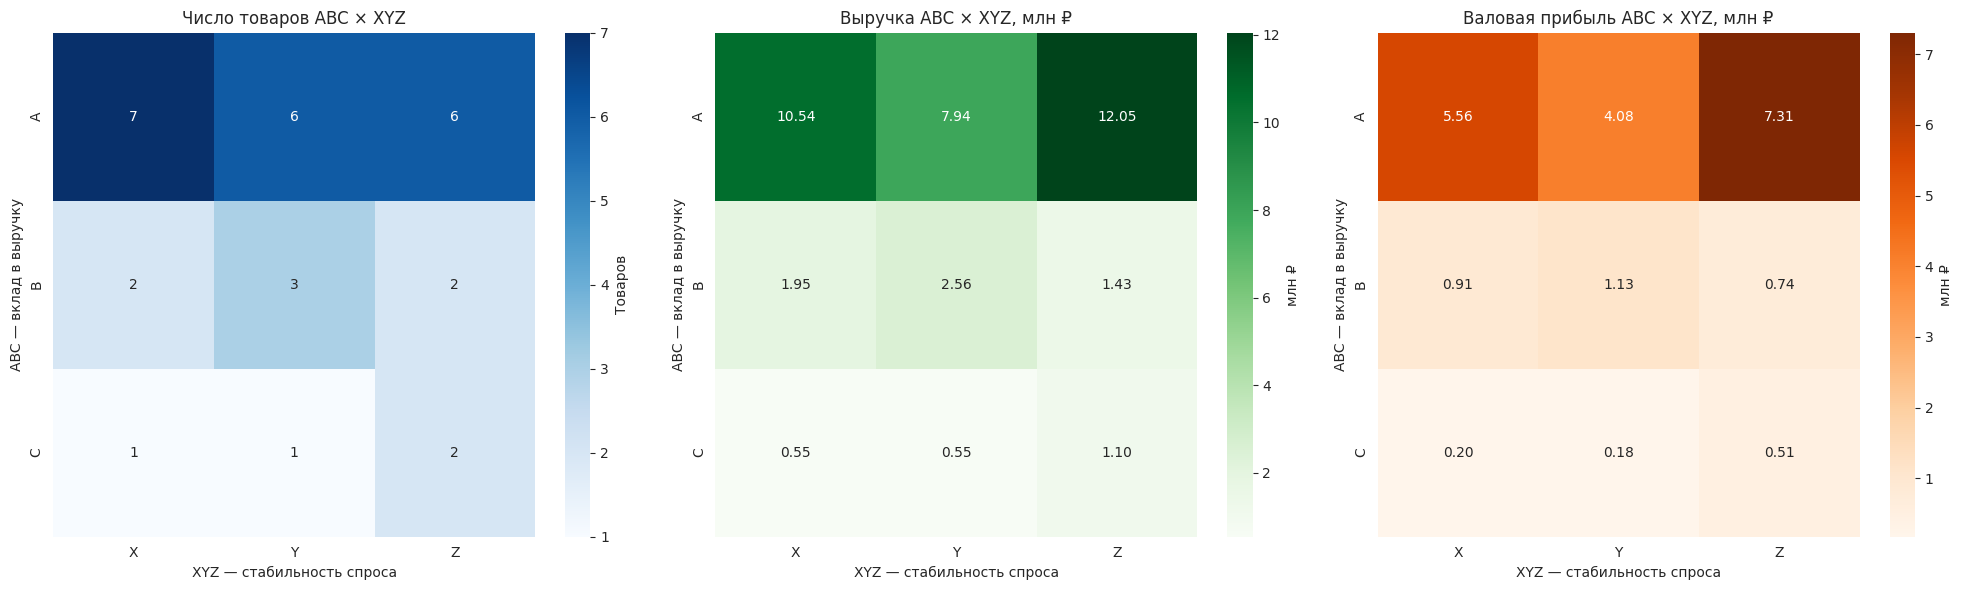


=== AX (7 товаров) ===


,product_name,category,revenue,profit,CV_pct
0,Филадельфия классическая,Суши,"1,850,063.50","941,897.42",33.68
1,Калифорния,Суши,"1,690,286.50","859,331.23",31.83
2,Пепперони,Пицца,"1,654,261.00","910,370.94",35.54
3,Удон с курицей,Wok,"1,493,039.00","815,716.47",35.11
4,Маргарита,Пицца,"1,428,756.00","765,964.92",32.70
5,Четыре сыра,Пицца,"1,242,374.50","675,961.83",35.60
6,Чикен бургер,Бургеры,"1,185,381.00","588,484.26",36.37



=== AY (6 товаров) ===


,product_name,category,revenue,profit,CV_pct
0,Дракон,Суши,"1,683,388.50","865,836.08",37.62
1,Запечённый лосось,Суши,"1,405,777.00","698,405.00",38.01
2,Чизбургер,Бургеры,"1,244,984.50","640,986.42",37.76
3,Тунец спайси,Суши,"1,237,019.00","618,333.09",37.37
4,Пад тай,Wok,"1,229,940.50","661,243.07",38.38
5,Бургер BBQ,Бургеры,"1,141,324.50","590,711.51",36.70



=== AZ (6 товаров) ===


...


=== CY (1 товаров) ===


,product_name,category,revenue,profit,CV_pct
0,Морс,Напитки,"554,624.00","176,980.59",38.11



=== CZ (2 товаров) ===


,product_name,category,revenue,profit,CV_pct
0,Чизкейк,Десерты,"622,059.00","293,613.24",40.60
1,Моти,Десерты,"479,978.00","217,329.22",43.64



✅ Файлы сохранены в /content/drive/MyDrive/1/


In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# =========================================================
# 1. Готовим недельные продажи по каждому товару
# =========================================================
df = orders_valid.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
df['week'] = df['order_date'].dt.to_period('W').dt.start_time

weekly = (df
    .groupby(['product_id', 'week'])
    .agg(revenue=('order_total', 'sum'), qty=('quantity', 'sum'))
    .reset_index()
)

# Полная сетка product × week (заполняем пропуски нулями)
all_weeks = weekly['week'].unique()
all_products = weekly['product_id'].unique()

full_index = pd.MultiIndex.from_product(
    [all_products, all_weeks], names=['product_id', 'week']
)
weekly_full = (weekly
    .set_index(['product_id', 'week'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# =========================================================
# 2. XYZ-метрики на уровне SKU (квантильные пороги)
# =========================================================
xyz = (weekly_full
    .groupby('product_id')
    .agg(
        mean_revenue=('revenue', 'mean'),
        std_revenue=('revenue', 'std'),
        mean_qty=('qty', 'mean'),
        std_qty=('qty', 'std'),
        weeks_count=('week', 'count'),
    )
    .reset_index()
)

xyz['CV'] = xyz['std_revenue'] / xyz['mean_revenue'].replace(0, np.nan)
xyz['CV_pct'] = xyz['CV'] * 100

# --- Квантильные пороги (терцили) ---
q33 = xyz['CV'].quantile(0.33)
q67 = xyz['CV'].quantile(0.67)

def xyz_group_quantile(cv):
    if pd.isna(cv):  return 'Z'
    if cv <= q33:    return 'X'
    elif cv <= q67:  return 'Y'
    else:            return 'Z'

xyz['XYZ'] = xyz['CV'].apply(xyz_group_quantile)

print(f"Пороги XYZ (SKU, квантили): X ≤ {q33:.2%},  Y ≤ {q67:.2%},  Z > {q67:.2%}")
print("\nРаспределение SKU по XYZ:")
print(xyz['XYZ'].value_counts().reindex(['X','Y','Z']))

# =========================================================
# 3. XYZ на уровне КАТЕГОРИЙ (классические пороги)
# =========================================================
weekly_cat = weekly_full.merge(
    products[['product_id', 'category']], on='product_id', how='left'
)

weekly_cat_agg = (weekly_cat
    .groupby(['category', 'week'])
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

xyz_cat = (weekly_cat_agg
    .groupby('category')
    .agg(mean_rev=('revenue', 'mean'), std_rev=('revenue', 'std'))
    .reset_index()
)
xyz_cat['CV'] = xyz_cat['std_rev'] / xyz_cat['mean_rev']
xyz_cat['CV_pct'] = xyz_cat['CV'] * 100

def xyz_cat_group(cv):
    if cv < 0.10:   return 'X'
    elif cv < 0.25: return 'Y'
    else:           return 'Z'

xyz_cat['XYZ'] = xyz_cat['CV'].apply(xyz_cat_group)

print("\nXYZ по категориям (классические пороги 10% / 25%):")
display(xyz_cat[['category', 'mean_rev', 'std_rev', 'CV_pct', 'XYZ']]
        .sort_values('CV_pct'))

# =========================================================
# 4. Объединяем ABC и XYZ
# =========================================================
abc_xyz = (abc
    .merge(xyz[['product_id', 'CV_pct', 'XYZ']], on='product_id', how='left')
)

# --- Матрица ABC × XYZ: количество товаров ---
pivot_count = abc_xyz.pivot_table(
    index='ABC', columns='XYZ', values='product_id',
    aggfunc='count', fill_value=0
).reindex(index=['A','B','C'], columns=['X','Y','Z'], fill_value=0)

# --- Матрица ABC × XYZ: выручка ---
pivot_revenue = abc_xyz.pivot_table(
    index='ABC', columns='XYZ', values='revenue',
    aggfunc='sum', fill_value=0
).reindex(index=['A','B','C'], columns=['X','Y','Z'], fill_value=0)

# --- Матрица ABC × XYZ: валовая прибыль ---
pivot_profit = abc_xyz.pivot_table(
    index='ABC', columns='XYZ', values='profit',
    aggfunc='sum', fill_value=0
).reindex(index=['A','B','C'], columns=['X','Y','Z'], fill_value=0)

print("Число товаров в матрице ABC × XYZ:")
display(pivot_count)

print("\nВыручка в матрице ABC × XYZ, ₽:")
display(pivot_revenue)

print("\nВаловая прибыль в матрице ABC × XYZ, ₽:")
display(pivot_profit)

# =========================================================
# 5. Тепловые карты матрицы
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(pivot_count, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Товаров'})
axes[0].set_title('Число товаров ABC × XYZ')
axes[0].set_xlabel('XYZ — стабильность спроса')
axes[0].set_ylabel('ABC — вклад в выручку')

sns.heatmap(pivot_revenue / 1e6, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'млн ₽'})
axes[1].set_title('Выручка ABC × XYZ, млн ₽')
axes[1].set_xlabel('XYZ — стабильность спроса')
axes[1].set_ylabel('ABC — вклад в выручку')

sns.heatmap(pivot_profit / 1e6, annot=True, fmt='.2f', cmap='Oranges', ax=axes[2],
            cbar_kws={'label': 'млн ₽'})
axes[2].set_title('Валовая прибыль ABC × XYZ, млн ₽')
axes[2].set_xlabel('XYZ — стабильность спроса')
axes[2].set_ylabel('ABC — вклад в выручку')

plt.tight_layout()
plt.show()

# =========================================================
# 6. Детальный список по каждой ячейке матрицы
# =========================================================
for abc_grp in ['A','B','C']:
    for xyz_grp in ['X','Y','Z']:
        sub = abc_xyz[(abc_xyz['ABC'] == abc_grp) & (abc_xyz['XYZ'] == xyz_grp)]
        if len(sub) > 0:
            print(f"\n=== {abc_grp}{xyz_grp} ({len(sub)} товаров) ===")
            display(sub[['product_name','category','revenue','profit','CV_pct']]
                    .sort_values('revenue', ascending=False)
                    .reset_index(drop=True))

# =========================================================
# 7. Сохраняем итоговые таблицы для дашборда
# =========================================================
abc_xyz.to_csv('/content/drive/MyDrive/1/abc_xyz_result.csv', index=False)
xyz_cat.to_csv('/content/drive/MyDrive/1/xyz_categories.csv', index=False)
pivot_count.to_csv('/content/drive/MyDrive/1/abc_xyz_count.csv')
pivot_revenue.to_csv('/content/drive/MyDrive/1/abc_xyz_revenue.csv')
pivot_profit.to_csv('/content/drive/MyDrive/1/abc_xyz_profit.csv')

print("\n✅ Файлы сохранены в /content/drive/MyDrive/1/")

Ключевые бизнес-выводы
Матрица ABC × XYZ показала три зоны решений:

* AX + AY (13 товаров) — защищать и планировать. Это 25M ₽ выручки и 14M ₽ прибыли.
* AZ (6 товаров) — риск out-of-stock. Нужен страховой запас и пересчёт XYZ по
* CZ + BZ (4 товара) — выводить.

Сеты — стратегический риск. Они самые прибыльные, но попали в AZ из-за волатильности в рублях. Нужно пересчитать XYZ по количеству заказов — это уберёт артефакт.

Хвост (C) занимает 5.5% выручки, но 13% SKU. Вывод Чизкейка, Моти, Лимонада и Морса освободит ресурсы кухни и упростит закупки.

Категорийный XYZ не разделил категории — все в Z. Это подтверждает: на уровне отдельного SKU волатильность высокая, на уровне категории — тоже. Для планирования нужен другой подход: скользящее среднее, сезонная декомпозиция или модель прогнозирования.

# 5. RFM-анализ клиентов

         segment  customers  avg_recency  avg_frequency  avg_monetary  \
0        At Risk       2840       394.15           4.51      4,178.65   
1          Loyal       2543       153.47           4.34      4,029.11   
2  New/Promising       2101        47.17           1.67      1,516.23   
3           Lost       1925       434.46           1.79      1,657.81   
4      Champions       1765        62.57           5.49      5,057.09   
5          Other        739       207.24           1.85      1,710.42   

   total_revenue  share_customers_%  share_revenue_%  
0  11,867,352.00              23.84            30.68  
1  10,246,027.50              21.35            26.49  
2   3,185,598.50              17.64             8.24  
3   3,191,290.50              16.16             8.25  
4   8,925,763.50              14.82            23.08  
5   1,264,004.00               6.20             3.27  


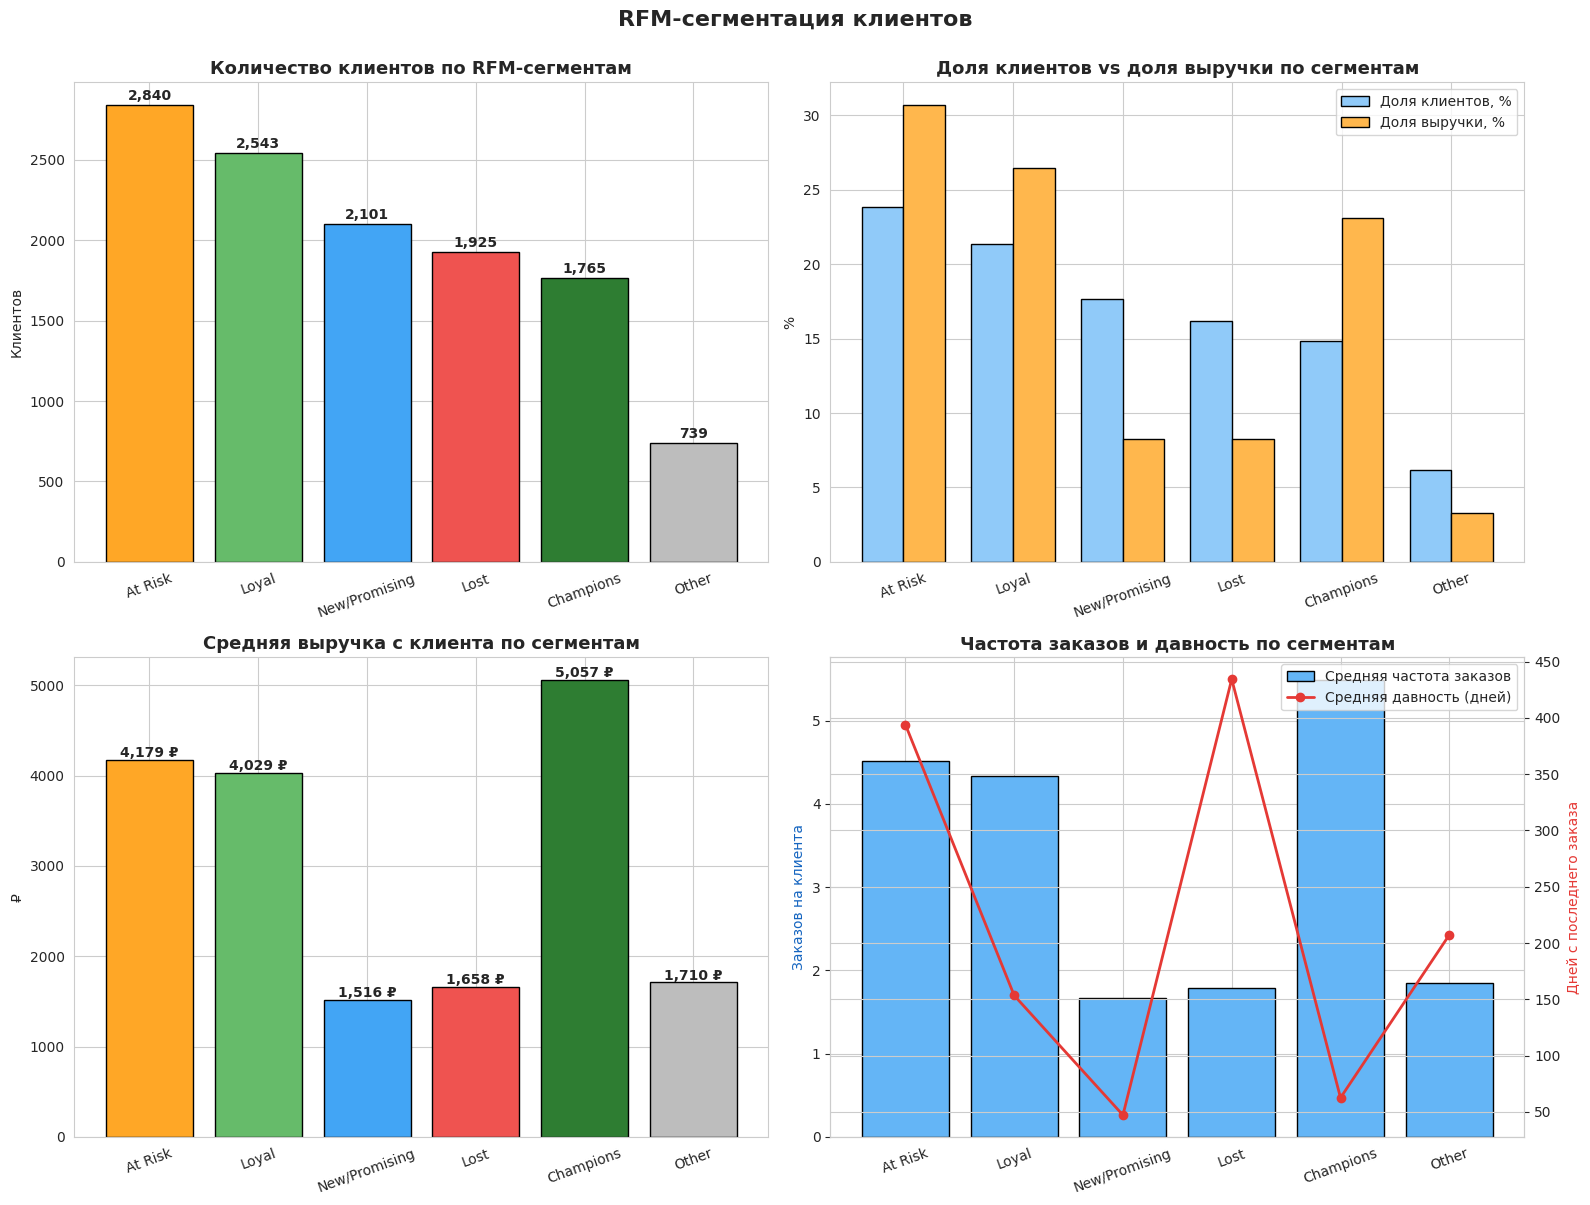

In [ ]:
# =========================================================
# 1. Добавляем выручку и средние метрики по сегментам
# =========================================================
rfm_summary = (rfm
    .groupby('segment')
    .agg(
        customers=('customer_id', 'count'),
        avg_recency=('Recency', 'mean'),
        avg_frequency=('Frequency', 'mean'),
        avg_monetary=('Monetary', 'mean'),
        total_revenue=('Monetary', 'sum'),
    )
    .reset_index()
)

# Сортируем по числу клиентов
rfm_summary = rfm_summary.sort_values('customers', ascending=False).reset_index(drop=True)

# Доля клиентов и доля выручки
rfm_summary['share_customers_%'] = rfm_summary['customers'] / rfm_summary['customers'].sum() * 100
rfm_summary['share_revenue_%']   = rfm_summary['total_revenue'] / rfm_summary['total_revenue'].sum() * 100

print(rfm_summary)

# =========================================================
# 2. Палитра по сегментам
# =========================================================
segment_colors = {
    'Champions':       '#2E7D32',  # тёмно-зелёный
    'Loyal':           '#66BB6A',  # зелёный
    'New/Promising':   '#42A5F5',  # синий
    'At Risk':         '#FFA726',  # оранжевый
    'Lost':            '#EF5350',  # красный
    'Other':           '#BDBDBD',  # серый
}

# =========================================================
# 3. Полотно 2×2
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- (1) Число клиентов по сегментам ---
order = rfm_summary['segment'].tolist()
colors = [segment_colors[s] for s in order]

bars = axes[0, 0].bar(order, rfm_summary['customers'], color=colors, edgecolor='black')
axes[0, 0].set_title('Количество клиентов по RFM-сегментам', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Клиентов')
axes[0, 0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, rfm_summary['customers']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 30,
                    f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# --- (2) Доля клиентов vs доля выручки ---
x = np.arange(len(order))
w = 0.38
axes[0, 1].bar(x - w/2, rfm_summary['share_customers_%'], width=w,
               label='Доля клиентов, %', color='#90CAF9', edgecolor='black')
axes[0, 1].bar(x + w/2, rfm_summary['share_revenue_%'], width=w,
               label='Доля выручки, %', color='#FFB74D', edgecolor='black')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(order, rotation=20)
axes[0, 1].set_title('Доля клиентов vs доля выручки по сегментам', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('%')
axes[0, 1].legend()

# --- (3) Средний чек по сегментам ---
bars = axes[1, 0].bar(order, rfm_summary['avg_monetary'], color=colors, edgecolor='black')
axes[1, 0].set_title('Средняя выручка с клиента по сегментам', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('₽')
axes[1, 0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, rfm_summary['avg_monetary']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 30,
                    f'{v:,.0f} ₽', ha='center', fontsize=10, fontweight='bold')

# --- (4) Средняя частота и Recency ---
ax = axes[1, 1]
ax2 = ax.twinx()

ax.bar(order, rfm_summary['avg_frequency'], color='#64B5F6',
       edgecolor='black', label='Средняя частота заказов')
ax2.plot(order, rfm_summary['avg_recency'], color='#E53935', marker='o',
         linewidth=2, label='Средняя давность (дней)')

ax.set_title('Частота заказов и давность по сегментам', fontsize=13, fontweight='bold')
ax.set_ylabel('Заказов на клиента', color='#1565C0')
ax2.set_ylabel('Дней с последнего заказа', color='#E53935')
ax.tick_params(axis='x', rotation=20)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('RFM-сегментация клиентов', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

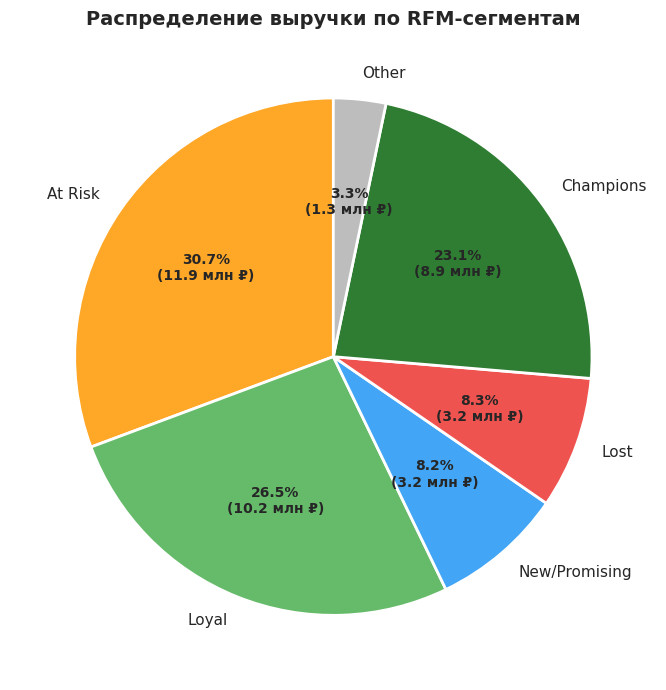

In [ ]:
# --- Круговая диаграмма: доля выручки по сегментам ---
fig, ax = plt.subplots(figsize=(9, 7))
colors_pie = [segment_colors[s] for s in rfm_summary['segment']]

wedges, texts, autotexts = ax.pie(
    rfm_summary['total_revenue'],
    labels=rfm_summary['segment'],
    autopct=lambda p: f'{p:.1f}%\n({p*rfm_summary["total_revenue"].sum()/100/1e6:.1f} млн ₽)',
    colors=colors_pie,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11),
)
for t in autotexts:
    t.set_fontsize(10); t.set_fontweight('bold')

ax.set_title('Распределение выручки по RFM-сегментам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

🚨 Проблема №1: At Risk — 30.68% выручки на грани потери
Бизнес сильно зависит от сегмента, который уходит. Если 2 840 клиентов At Risk не вернуть:

Потеря выручки: до 11.87 млн ₽

Переход в Lost = полная потеря LTV.

💡 Возможность: реактивация At Risk
Реактивация дешевле привлечения в 5–7 раз.

Если вернуть 15% At Risk (426 клиентов) со средним чеком 4 179 ₽ × 2 заказа = 3.56 млн ₽ дополнительной выручки без затрат на привлечение.

Промокод -20% + триггерная серия из 3 писем + push.

📊 Связь с анализом каналов
Помните: Яндекс Директ, VK Ads, Telegram дают ROMI < 10%. Гипотеза: именно из этих каналов пришли At Risk и Lost. Дорогое привлечение + отсутствие retention = уход клиентов.

## График перехода между RFM-сегментами

T1 = 2026-01-18,  T2 = 2026-09-30
Клиентов в T1: 7,188

Матрица переходов, % от исходного сегмента:


segment_t2,Champions,Loyal,New/Promising,At Risk,Lost,Other
segment_t1,,,,,,
Champions,8.10,52.80,0.00,39.10,0.00,0.00
Loyal,8.20,25.40,0.00,58.20,6.80,1.40
New/Promising,25.70,36.70,0.80,0.00,16.60,20.20
At Risk,0.20,0.60,0.00,88.70,10.50,0.00
Lost,0.40,1.10,0.00,0.00,98.10,0.40
Other,10.70,17.30,0.20,0.00,65.30,6.50



Абсолютные значения:


segment_t2,Champions,Loyal,New/Promising,At Risk,Lost,Other
segment_t1,,,,,,
Champions,86,560,0,415,0,0
Loyal,123,383,0,876,103,21
New/Promising,320,458,10,0,207,252
At Risk,4,10,0,1549,183,0
Lost,4,12,0,0,1103,5
Other,54,87,1,0,329,33


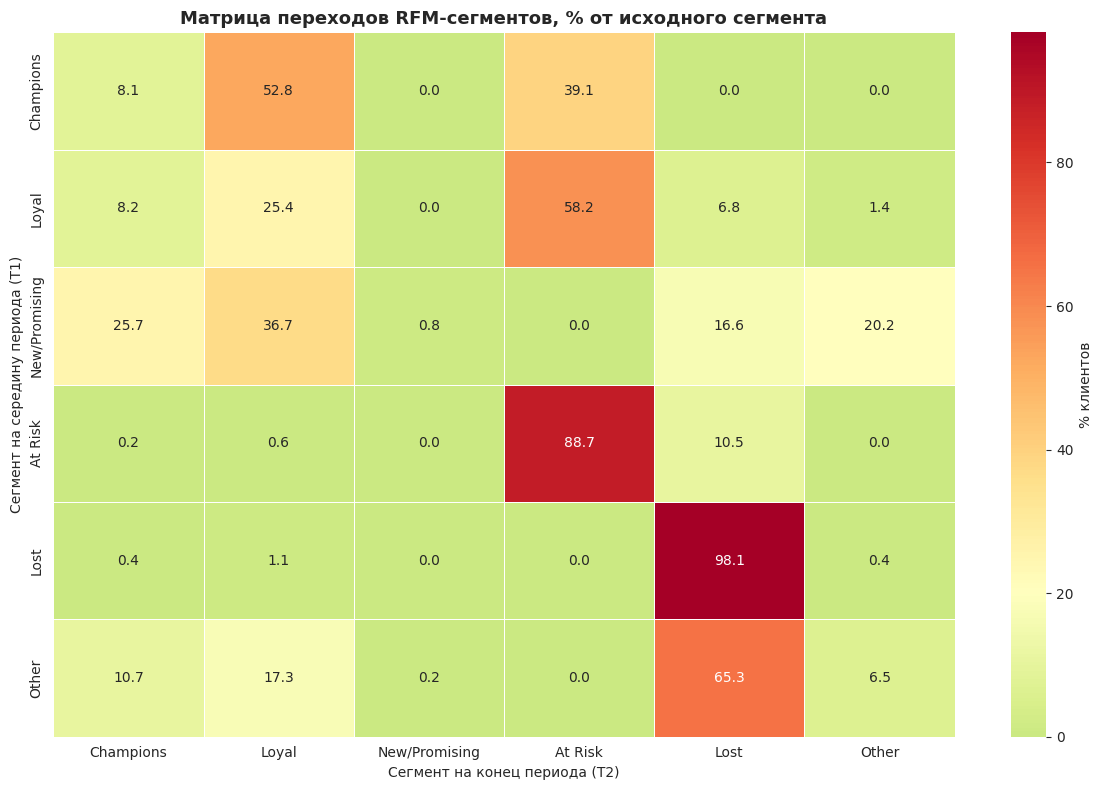

In [ ]:
# =========================================================
# 1. Функция для расчёта RFM на заданную дату
# =========================================================
def compute_rfm(orders_df, snapshot_date):
    """Считает RFM и присваивает сегменты на заданную дату."""
    df = orders_df[orders_df['order_date'] <= snapshot_date].copy()

    rfm = (df
        .groupby('customer_id')
        .agg(
            Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
            Frequency=('order_id', 'nunique'),
            Monetary=('order_total', 'sum'),
        )
        .reset_index()
    )

    # Квантильные оценки
    rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
    rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5,
                       labels=[1,2,3,4,5]).astype(int)
    rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

    def seg(row):
        if row['R'] >= 4 and row['F'] >= 4: return 'Champions'
        if row['R'] >= 3 and row['F'] >= 3: return 'Loyal'
        if row['R'] >= 4 and row['F'] <= 2: return 'New/Promising'
        if row['R'] <= 2 and row['F'] >= 3: return 'At Risk'
        if row['R'] <= 2 and row['F'] <= 2: return 'Lost'
        return 'Other'

    rfm['segment'] = rfm.apply(seg, axis=1)
    return rfm[['customer_id', 'segment']]

# =========================================================
# 2. Считаем RFM на две даты
# =========================================================
# Период T1 — середина данных, период T2 — конец
min_date = orders_valid['order_date'].min()
max_date = orders_valid['order_date'].max()

date_t1 = min_date + (max_date - min_date) * 0.6   # 60% периода
date_t2 = max_date                                  # конец периода

rfm_t1 = compute_rfm(orders_valid, date_t1).rename(columns={'segment': 'segment_t1'})
rfm_t2 = compute_rfm(orders_valid, date_t2).rename(columns={'segment': 'segment_t2'})

# Оставляем только клиентов, которые были активны в T1
transition = rfm_t1.merge(rfm_t2, on='customer_id', how='left')
transition['segment_t2'] = transition['segment_t2'].fillna('Churned')

print(f"T1 = {date_t1.date()},  T2 = {date_t2.date()}")
print(f"Клиентов в T1: {len(transition):,}")

# =========================================================
# 3. Матрица переходов (доля от исходного сегмента)
# =========================================================
segment_order = ['Champions','Loyal','New/Promising','At Risk','Lost','Other','Churned']

trans_matrix = pd.crosstab(
    transition['segment_t1'],
    transition['segment_t2'],
    normalize='index'  # доли от исходного сегмента
) * 100

# Упорядочиваем
trans_matrix = trans_matrix.reindex(
    index=[s for s in segment_order if s in trans_matrix.index],
    columns=[s for s in segment_order if s in trans_matrix.columns],
    fill_value=0
)
print("\nМатрица переходов, % от исходного сегмента:")
display(trans_matrix.round(1))

# Абсолютные значения
trans_counts = pd.crosstab(transition['segment_t1'], transition['segment_t2'])
trans_counts = trans_counts.reindex(
    index=[s for s in segment_order if s in trans_counts.index],
    columns=[s for s in segment_order if s in trans_counts.columns],
    fill_value=0
)
print("\nАбсолютные значения:")
display(trans_counts)
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    trans_matrix,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r', center=20,
    cbar_kws={'label': '% клиентов'},
    linewidths=0.5, linecolor='white', ax=ax
)
ax.set_title('Матрица переходов RFM-сегментов, % от исходного сегмента',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Сегмент на конец периода (T2)')
ax.set_ylabel('Сегмент на середину периода (T1)')
plt.tight_layout()
plt.show()

(а) Проблема — удержание, а не привлечение.

39% Champions и 58% Loyal деградировали в At Risk.

Это значит: клиенты покупают 1–3 раза, потом уходят.

Привлечение новых работает (New/Promising → Loyal 36.7%), но удержание — нет.

(б) At Risk — это болото.

88.7% застревают.

Без реактивации они перейдут в Lost в течение следующих 6 месяцев.

(в) Связь с анализом каналов.

Помните: Яндекс/VK/Telegram дают ROMI < 10%.

Гипотеза: оттуда приходят клиенты, которые быстро уходят в At Risk.

Если это подтвердится — бюджет на эти каналы надо сокращать, а деньги перенаправлять в retention.

(г) Экономический эффект.

415 Champions ушли в At Risk. При среднем чеке 5 057 ₽ × 3 заказа = ~6.3 млн ₽ потерянной выручки.

876 Loyal ушли в At Risk. При чеке 4 029 ₽ × 2 заказа = ~7 млн ₽.

Итого: ~13 млн ₽ выручки под угрозой.

from IPython.display import Markdown, display

md = """
###  Рекомендации по итогам RFM и матрицы переходов

| # | Приоритет | Действие | Сегмент | Механика | Ожидаемый эффект |
|---|---|---|---|---|---|
| 1 | 🔴 | **Реактивация At Risk** | At Risk (1 549) | Промокод −20% + триггерная серия | **+3–4 млн ₽** |
| 2 | 🔴 | **Программа лояльности** | Loyal (876 ушли в At Risk) | Бонусы, кэшбэк, статус | Остановить утечку ~7 млн ₽ |
| 3 | 🟠 | **VIP-программа** | Champions (415 ушли) | Ранний доступ, без скидок | Вернуть ~6 млн ₽ |
| 4 | 🟠 | **Welcome-серия** | New/Promising (207 в Lost) | Промо на 2-й заказ | Удержать 5–7% |
| 5 | 🟡 | **Пересмотр бюджета** | Яндекс / VK / Telegram | Сократить на 30–50% | Высвободить ~5.5 млн ₽ |

> **Итог:** сместить фокус с привлечения на удержание и реактивацию.
> Реактивация в 5–7 раз дешевле привлечения, а суммарный эффект — **+10–13 млн ₽** без роста бюджета.
"""
display(Markdown(md))


## Метрики по сегментам

In [ ]:
rfm_summary = (rfm.groupby('segment')
    .agg(
        customers=('customer_id','count'),
        avg_recency=('Recency','mean'),
        avg_frequency=('Frequency','mean'),
        avg_monetary=('Monetary','mean'),
        total_revenue=('Monetary','sum'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
rfm_summary

,segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue
0,At Risk,2840,394.15,4.51,"4,178.65","11,867,352.00"
3,Loyal,2543,153.47,4.34,"4,029.11","10,246,027.50"
1,Champions,1765,62.57,5.49,"5,057.09","8,925,763.50"
2,Lost,1925,434.46,1.79,"1,657.81","3,191,290.50"
4,New/Promising,2101,47.17,1.67,"1,516.23","3,185,598.50"
5,Other,739,207.24,1.85,"1,710.42","1,264,004.00"


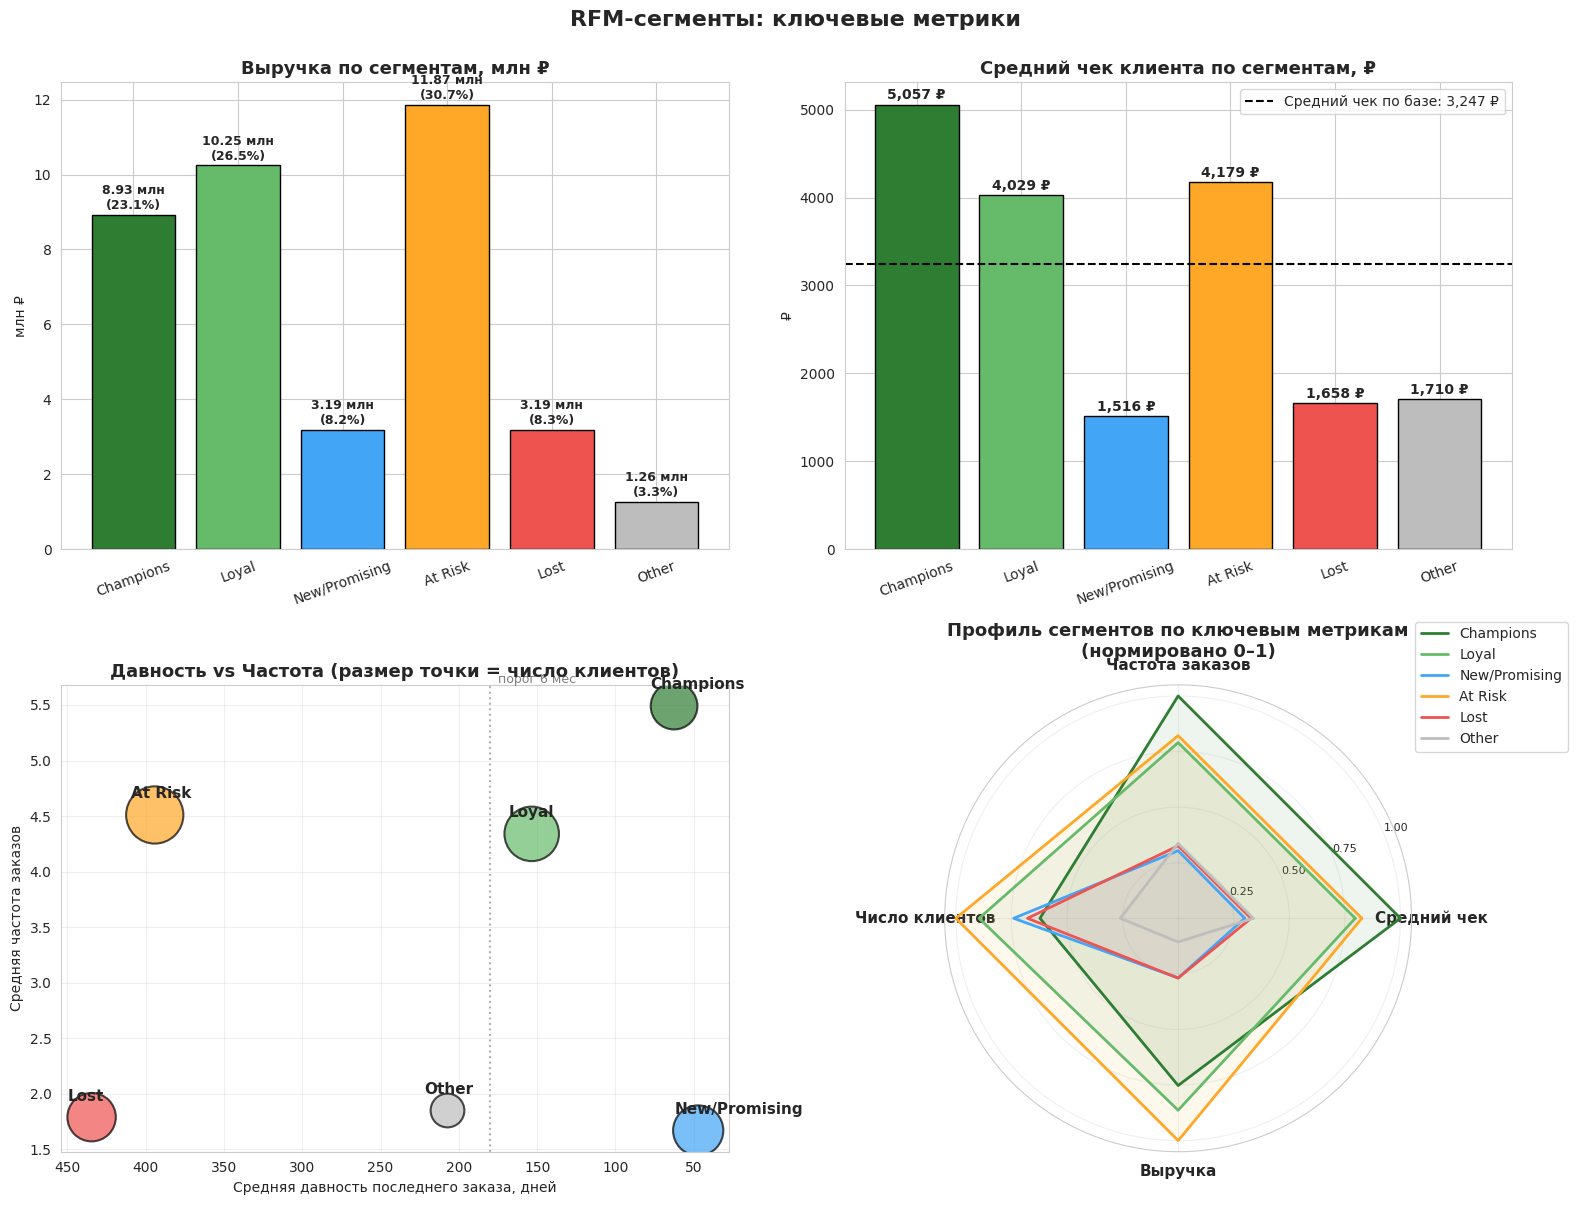

In [ ]:
sns.set_style('whitegrid')

# =========================================================
# 1. Данные
# =========================================================
metrics = pd.DataFrame({
    'Сегмент':          ['At Risk', 'Loyal', 'Champions', 'Lost', 'New/Promising', 'Other'],
    'Клиентов':         [2840, 2543, 1765, 1925, 2101, 739],
    'Ср_давность':      [394.15, 153.47, 62.57, 434.46, 47.17, 207.24],
    'Ср_частота':       [4.51, 4.34, 5.49, 1.79, 1.67, 1.85],
    'Ср_чек':           [4178.65, 4029.11, 5057.09, 1657.81, 1516.23, 1710.42],
    'Выручка':          [11867352.00, 10246027.50, 8925763.50, 3191290.50, 3185598.50, 1264004.00],
})
metrics['Доля_выручки'] = metrics['Выручка'] / metrics['Выручка'].sum() * 100
metrics['Выручка_на_клиента'] = metrics['Выручка'] / metrics['Клиентов']

# Порядок для отображения
order = ['Champions', 'Loyal', 'New/Promising', 'At Risk', 'Lost', 'Other']
metrics = metrics.set_index('Сегмент').reindex(order).reset_index()

# =========================================================
# 2. Палитра
# =========================================================
palette = {
    'Champions':     '#2E7D32',
    'Loyal':         '#66BB6A',
    'New/Promising': '#42A5F5',
    'At Risk':       '#FFA726',
    'Lost':          '#EF5350',
    'Other':         '#BDBDBD',
}
colors = [palette[s] for s in metrics['Сегмент']]

# =========================================================
# 3. Полотно 2×2
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- (1) Выручка и доля выручки ---
ax = axes[0, 0]
bars = ax.bar(metrics['Сегмент'], metrics['Выручка'] / 1e6,
              color=colors, edgecolor='black', linewidth=1)
ax.set_title('Выручка по сегментам, млн ₽', fontsize=13, fontweight='bold')
ax.set_ylabel('млн ₽')
ax.tick_params(axis='x', rotation=20)
for bar, v, share in zip(bars, metrics['Выручка'] / 1e6, metrics['Доля_выручки']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.15,
            f'{v:.2f} млн\n({share:.1f}%)',
            ha='center', fontsize=9, fontweight='bold')

# --- (2) Средний чек по сегментам ---
ax = axes[0, 1]
bars = ax.bar(metrics['Сегмент'], metrics['Ср_чек'],
              color=colors, edgecolor='black', linewidth=1)
avg_check = metrics['Выручка'].sum() / metrics['Клиентов'].sum()
ax.axhline(avg_check, color='black', linestyle='--', linewidth=1.5,
           label=f'Средний чек по базе: {avg_check:,.0f} ₽')
ax.set_title('Средний чек клиента по сегментам, ₽', fontsize=13, fontweight='bold')
ax.set_ylabel('₽')
ax.tick_params(axis='x', rotation=20)
ax.legend()
for bar, v in zip(bars, metrics['Ср_чек']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 60,
            f'{v:,.0f} ₽', ha='center', fontsize=10, fontweight='bold')

# --- (3) Давность vs Частота (scatter) ---
ax = axes[1, 0]
sizes = metrics['Клиентов'] / metrics['Клиентов'].max() * 1500 + 200
ax.scatter(metrics['Ср_давность'], metrics['Ср_частота'],
           s=sizes, c=colors, alpha=0.7, edgecolors='black', linewidth=1.5)
for _, row in metrics.iterrows():
    ax.annotate(row['Сегмент'],
                xy=(row['Ср_давность'], row['Ср_частота']),
                xytext=(row['Ср_давность'] + 15, row['Ср_частота'] + 0.15),
                fontsize=11, fontweight='bold')
ax.set_xlabel('Средняя давность последнего заказа, дней')
ax.set_ylabel('Средняя частота заказов')
ax.set_title('Давность vs Частота (размер точки = число клиентов)',
             fontsize=13, fontweight='bold')
ax.invert_xaxis()  # Чем левее — тем свежее, это удобнее
ax.axvline(180, color='gray', linestyle=':', alpha=0.6)
ax.text(180, 5.7, '  порог 6 мес', color='gray', fontsize=9)
ax.grid(True, alpha=0.3)

# --- (4) Radar chart ---
ax = axes[1, 1]
ax.remove()
ax = fig.add_subplot(2, 2, 4, polar=True)

# Метрики для radar: нормируем 0–1
radar_metrics = ['Ср_чек', 'Ср_частота', 'Клиентов', 'Выручка']
radar_labels  = ['Средний чек', 'Частота заказов', 'Число клиентов', 'Выручка']
N = len(radar_metrics)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # замкнуть круг

# Нормировка
data_norm = metrics[radar_metrics].copy()
for col in radar_metrics:
    data_norm[col] = data_norm[col] / data_norm[col].max()

for i, row in data_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2,
            color=palette[metrics['Сегмент'].iloc[i]],
            label=metrics['Сегмент'].iloc[i])
    ax.fill(angles, values, alpha=0.08,
            color=palette[metrics['Сегмент'].iloc[i]])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11, fontweight='bold')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_title('Профиль сегментов по ключевым метрикам\n(нормировано 0–1)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('RFM-сегменты: ключевые метрики', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

1. At Risk — крупнейший по выручке, но «протекающий»
30.7% выручки — на клиентах, которые не покупали 13+ месяцев.

По частоте они такие же, как Loyal — значит, это ушедшие лояльные.

Если не вернуть — потеря 11.87 млн ₽.

2. Champions — ядро, но их мало
15% клиентов → 23% выручки.

Средний чек 5 057 ₽ — самый высокий.

Давность 63 дня — покупают сейчас.

Их нужно защищать (не давать скидок, только VIP).

3. New/Promising — критическая зона
1 516 ₽ средний чек — в 3.3 раза ниже Champions.

47 дней давности — свежие.

Окно удержания — 60–90 дней. Если не удержать — уйдут в Lost.

4. Lost + Other — терминал
8.3% + 3.3% = 11.6% выручки.

Реактивация нецелесообразна.



# 6. Когортный анализ удержания

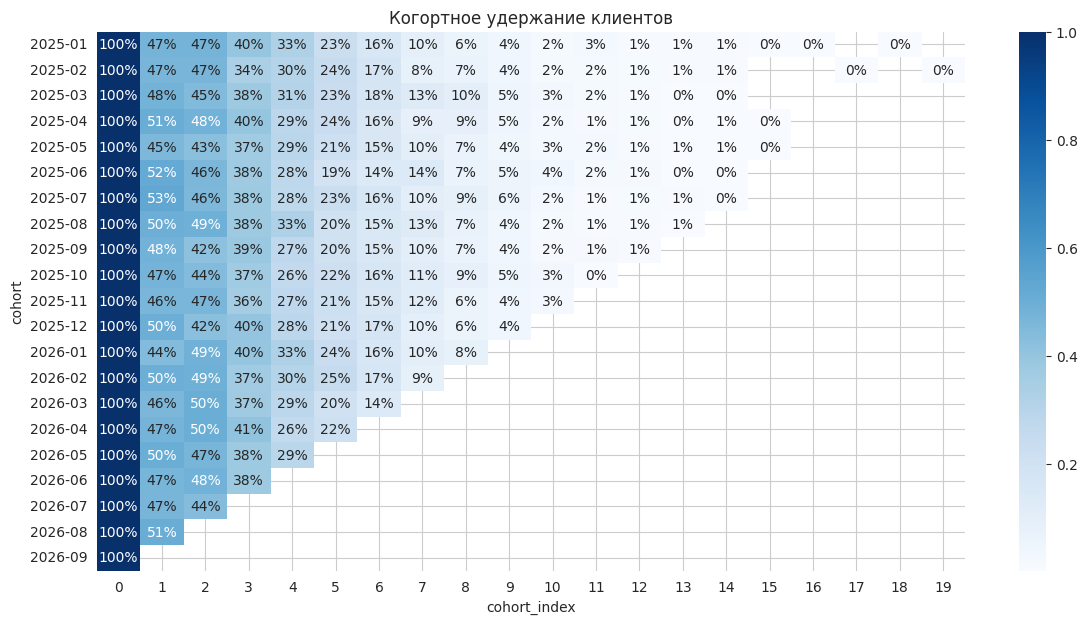

In [ ]:
orders_valid['cohort'] = orders_valid.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')
orders_valid['order_period'] = orders_valid['order_date'].dt.to_period('M')
orders_valid['cohort_index'] = (orders_valid['order_period'] - orders_valid['cohort']).apply(lambda x: x.n)

cohort = (orders_valid
    .groupby(['cohort','cohort_index'])
    .agg(customers=('customer_id','nunique'))
    .reset_index()
)

cohort_pivot = cohort.pivot(index='cohort', columns='cohort_index', values='customers')
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0)

plt.figure(figsize=(14,7))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues')
plt.title('Когортное удержание клиентов')
plt.show()

 (рекомендации)
(а) Программа удержания на 3-й заказ
Гипотеза: если клиент сделал 3 заказа, он с большой вероятностью останется надолго.

Механика: триггерное промо после 2-го заказа — «-15% на 3-й заказ в течение 14 дней».

Цель: повысить M3 retention с 38% до 45%.

(б) Работа с «точкой оттока» на M4–M6
Через 4 месяца retention падает в 2 раза.

Механика: реактивационная серия на M4 — push + email + промокод -20%.

Цель: удержать 10–15% уходящих.

(в) Сегментировать когорты по каналу
Разные когорты могут иметь разный retention в зависимости от канала привлечения.

Гипотеза: Яндекс/VK/Telegram дают когорты с retention в M3 < 30%. Органика — > 50%.

Если подтвердится — перераспределить бюджет в каналы с лучшим retention.

(г) Когортный LTV
Retention в M1–M3 у разных когорт отличается на 5–10 п.п.

При среднем чеке 3 247 ₽ и частоте 3 заказа это ~500–1 000 ₽ разницы в LTV на клиента.

Умножаем на тысячи клиентов — получаем миллионы рублей.

# 7. LTV и CAC по каналам

In [ ]:
# LTV (упрощённо): средний чек × частота × срок жизни
ltv = (orders_valid
    .groupby('acquisition_channel')
    .agg(
        revenue=('order_total','sum'),
        orders=('order_id','nunique'),
        customers=('customer_id','nunique'),
    )
    .reset_index()
)
ltv['AOV'] = ltv['revenue'] / ltv['orders']
ltv['orders_per_customer'] = ltv['orders'] / ltv['customers']
ltv['LTV'] = ltv['AOV'] * ltv['orders_per_customer']

# CAC
cac = marketing_daily.groupby('channel').agg(
    spend=('spend','sum'),
    new_customers=('new_customers','sum')
).reset_index()
cac['CAC'] = cac['spend'] / cac['new_customers']

# Сравнение LTV / CAC
ltv_cac = ltv.merge(cac[['channel','CAC']], left_on='acquisition_channel', right_on='channel', how='left')
ltv_cac['LTV_CAC'] = ltv_cac['LTV'] / ltv_cac['CAC']
ltv_cac.sort_values('LTV_CAC', ascending=False)

,acquisition_channel,revenue,orders,customers,AOV,orders_per_customer,LTV,channel,CAC,LTV_CAC
5,Яндекс Директ,"8,729,347.50",9362,2614,932.42,3.58,"3,339.46",Яндекс Директ,37.37,89.37
4,Реферальная программа,"5,674,976.00",6076,1777,934.00,3.42,"3,193.57",Реферальная программа,52.93,60.34
0,Email,"4,515,489.50",4984,1444,906.00,3.45,"3,127.07",Email,52.49,59.58
2,VK Ads,"6,403,359.00",6918,1995,925.61,3.47,"3,209.70",VK Ads,57.43,55.89
1,Telegram,"4,603,748.00",4971,1405,926.12,3.54,"3,276.69",Telegram,75.00,43.69
3,Органика,"8,753,116.00",9546,2678,916.94,3.56,"3,268.53",Органика,131.09,24.93


channel,spend,new_customers,CAC_client,LTV,LTV_CAC,ROMI_%
Органика,"591,340 ₽","2,554",232 ₽,"3,427 ₽",14.80x,1380.2%
Email,"1,446,922 ₽","1,362","1,062 ₽","3,315 ₽",3.12x,212.1%
Реферальная,"2,308,222 ₽","1,679","1,375 ₽","3,380 ₽",2.46x,145.9%
Яндекс Директ,"7,974,478 ₽","2,486","3,208 ₽","3,511 ₽",1.09x,9.5%
VK Ads,"5,935,408 ₽","1,879","3,159 ₽","3,408 ₽",1.08x,7.9%
Telegram,"4,270,057 ₽","1,337","3,194 ₽","3,443 ₽",1.08x,7.8%


/tmp/ipykernel_3711/3217146648.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


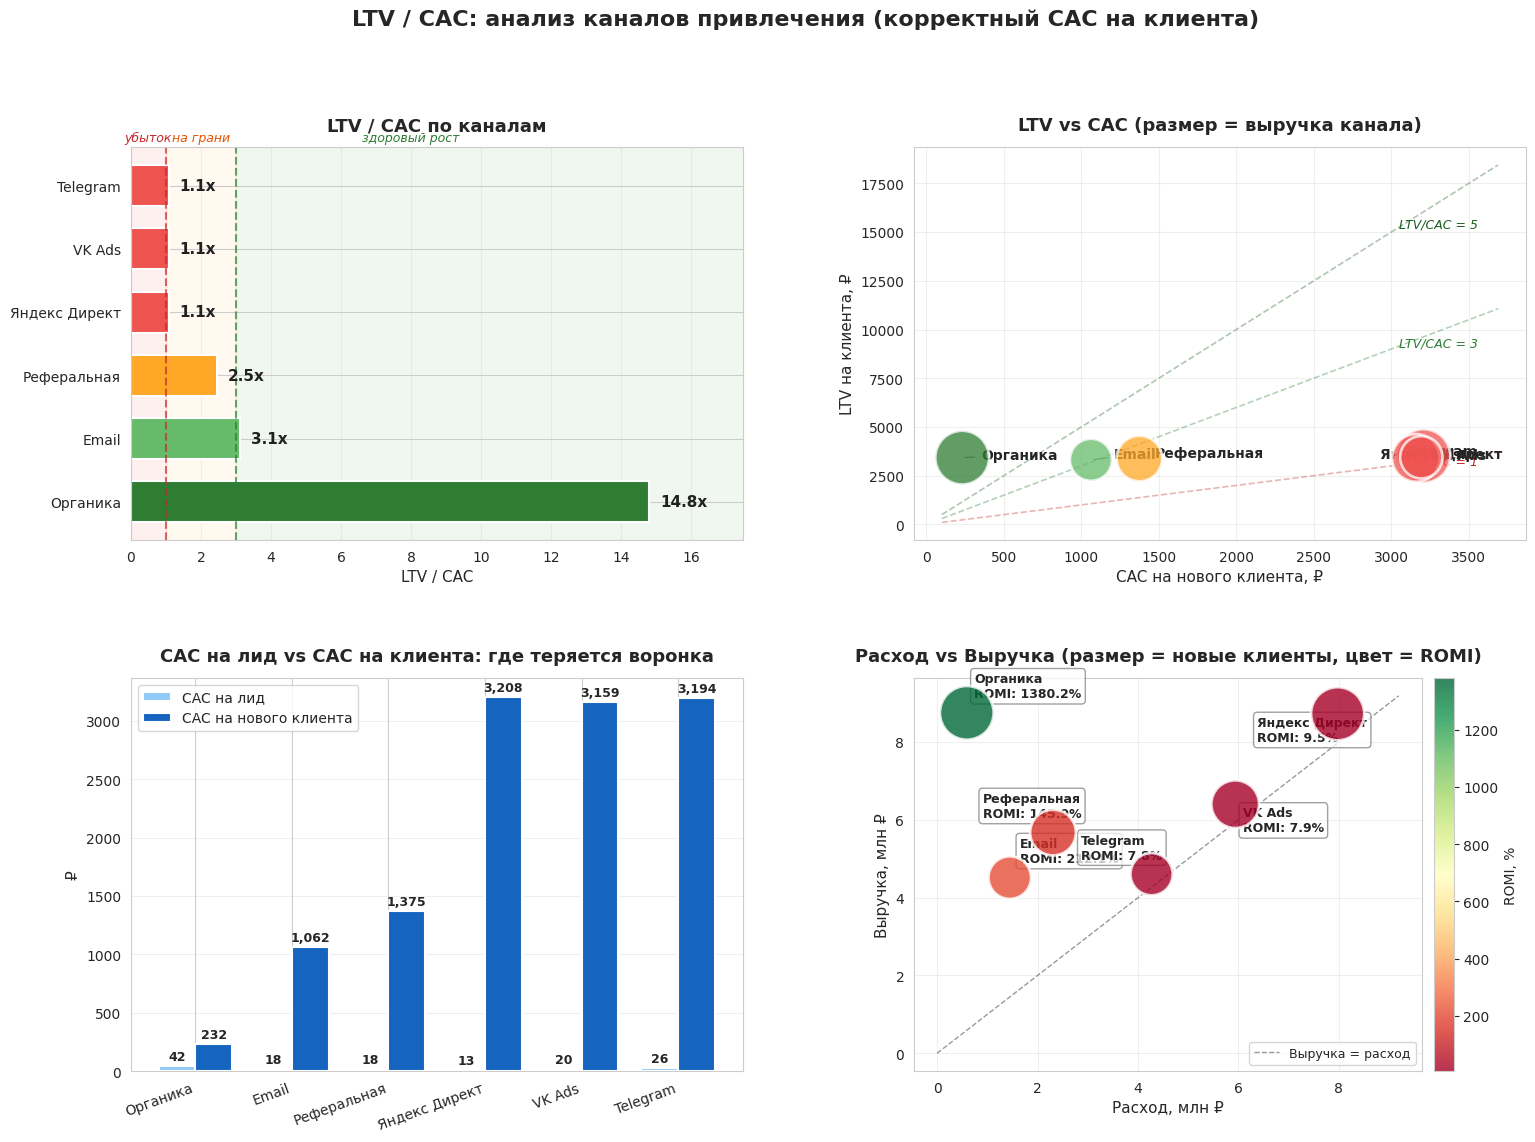

In [ ]:
# =========================================================
# 0. Импорты и настройки
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

# =========================================================
# 1. Данные с КОРРЕКТНЫМ CAC
# =========================================================
df = pd.DataFrame({
    'channel':       ['Органика', 'Email', 'Реферальная', 'Яндекс Директ', 'VK Ads', 'Telegram'],
    'spend':         [591340.21, 1446921.53, 2308222.09, 7974478.10, 5935408.10, 4270057.05],
    'leads':         [13959, 79730, 126955, 611456, 293707, 164021],
    'new_customers': [2554, 1362, 1679, 2486, 1879, 1337],
    'orders':        [9546, 4984, 6076, 9362, 6918, 4971],
    'revenue':       [8753116.00, 4515489.50, 5674976.00, 8729347.50, 6403359.00, 4603748.00],
})

# --- Метрики ---
df['CAC_lead']    = df['spend'] / df['leads']              # цена лида
df['CAC_client']  = df['spend'] / df['new_customers']      # НАСТОЯЩИЙ CAC
df['LTV']         = df['revenue'] / df['new_customers']    # выручка на клиента
df['LTV_CAC']     = df['LTV'] / df['CAC_client']
df['ROMI_%']      = (df['revenue'] - df['spend']) / df['spend'] * 100
df['spend_share_%'] = df['spend'] / df['spend'].sum() * 100

# --- Сортировка ---
df = df.sort_values('LTV_CAC', ascending=False).reset_index(drop=True)

# --- Цвета по здоровью LTV/CAC ---
def color_health(v):
    if v >= 5:    return '#2E7D32'   # тёмно-зелёный
    if v >= 3:    return '#66BB6A'   # зелёный
    if v >= 1.5:  return '#FFA726'   # оранжевый
    return '#EF5350'                 # красный

colors = [color_health(v) for v in df['LTV_CAC']]

# --- Вывод таблицы ---
display(df[['channel','spend','new_customers','CAC_client','LTV','LTV_CAC','ROMI_%']]
        .style.format({
            'spend': '{:,.0f} ₽',
            'new_customers': '{:,.0f}',
            'CAC_client': '{:,.0f} ₽',
            'LTV': '{:,.0f} ₽',
            'LTV_CAC': '{:.2f}x',
            'ROMI_%': '{:.1f}%',
        })
        .background_gradient(subset=['LTV_CAC'], cmap='RdYlGn')
        .hide(axis='index'))

# =========================================================
# 2. Дашборд 2×2 — чистый и профессиональный
# =========================================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.28)

# ---------------------------------------------------------
# График 1: LTV / CAC по каналам с зонами здоровья
# ---------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

bars = ax1.barh(df['channel'], df['LTV_CAC'], color=colors,
                edgecolor='white', linewidth=1.5, height=0.65)

# Зоны здоровья
ax1.axvspan(0, 1, alpha=0.06, color='red', zorder=0)
ax1.axvspan(1, 3, alpha=0.06, color='orange', zorder=0)
ax1.axvspan(3, 20, alpha=0.06, color='green', zorder=0)

ax1.axvline(1, color='#C62828', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.axvline(3, color='#2E7D32', linestyle='--', linewidth=1.5, alpha=0.7)

# Подписи зон
ax1.text(0.5, len(df)-0.3, 'убыток', color='#C62828',
         fontsize=9, ha='center', style='italic')
ax1.text(2, len(df)-0.3, 'на грани', color='#E65100',
         fontsize=9, ha='center', style='italic')
ax1.text(8, len(df)-0.3, 'здоровый рост', color='#2E7D32',
         fontsize=9, ha='center', style='italic')

# Значения на столбцах
for bar, v, cac in zip(bars, df['LTV_CAC'], df['CAC_client']):
    ax1.text(v + 0.3, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}x', va='center', fontsize=11,
             fontweight='bold', color='#212121')

ax1.set_xlim(0, df['LTV_CAC'].max() * 1.18)
ax1.set_xlabel('LTV / CAC', fontsize=11)
ax1.set_title('LTV / CAC по каналам', fontsize=13, fontweight='bold', pad=12)
ax1.grid(axis='x', alpha=0.3)
ax1.set_axisbelow(True)

# ---------------------------------------------------------
# График 2: LTV vs CAC (scatter с зонами)
# ---------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

# Линия LTV/CAC = 1, 3, 5
x_range = np.linspace(100, df['CAC_client'].max() * 1.15, 200)
for ratio, color, label in [(1, '#C62828', 'LTV/CAC = 1'),
                             (3, '#2E7D32', 'LTV/CAC = 3'),
                             (5, '#1B5E20', 'LTV/CAC = 5')]:
    ax2.plot(x_range, x_range * ratio, linestyle='--', color=color,
             alpha=0.35, linewidth=1.2)
    ax2.text(df['CAC_client'].max() * 0.95, df['CAC_client'].max() * 0.95 * ratio,
             label, color=color, fontsize=9, style='italic')

# Точки
sizes = df['revenue'] / df['revenue'].max() * 1200 + 300
ax2.scatter(df['CAC_client'], df['LTV'], s=sizes, c=colors,
            alpha=0.75, edgecolors='white', linewidth=2, zorder=5)

# Подписи каналов с автоматическим смещением
offsets = {
    'Органика':       (120, -60),
    'Email':          (150, 60),
    'Реферальная':    (100, 80),
    'Яндекс Директ':  (-280, -100),
    'VK Ads':         (100, -60),
    'Telegram':       (-100, 90),
}
for _, row in df.iterrows():
    dx, dy = offsets.get(row['channel'], (80, 40))
    ax2.annotate(row['channel'],
                 xy=(row['CAC_client'], row['LTV']),
                 xytext=(row['CAC_client'] + dx, row['LTV'] + dy),
                 fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

ax2.set_xlabel('CAC на нового клиента, ₽', fontsize=11)
ax2.set_ylabel('LTV на клиента, ₽', fontsize=11)
ax2.set_title('LTV vs CAC (размер = выручка канала)', fontsize=13,
              fontweight='bold', pad=12)
ax2.grid(True, alpha=0.3)
ax2.set_axisbelow(True)

# ---------------------------------------------------------
# График 3: CAC на лид vs CAC на клиента
# ---------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

x = np.arange(len(df))
w = 0.38

b1 = ax3.bar(x - w/2, df['CAC_lead'], width=w, color='#90CAF9',
             edgecolor='white', linewidth=1.5, label='CAC на лид')
b2 = ax3.bar(x + w/2, df['CAC_client'], width=w, color='#1565C0',
             edgecolor='white', linewidth=1.5, label='CAC на нового клиента')

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2, h + 50,
                 f'{h:,.0f}', ha='center', fontsize=9, fontweight='bold')

ax3.set_xticks(x)
ax3.set_xticklabels(df['channel'], rotation=20, ha='right')
ax3.set_ylabel('₽', fontsize=11)
ax3.set_title('CAC на лид vs CAC на клиента: где теряется воронка',
              fontsize=13, fontweight='bold', pad=12)
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(axis='y', alpha=0.3)
ax3.set_axisbelow(True)

# ---------------------------------------------------------
# График 4: Расход vs Выручка с пузырьками ROMI
# ---------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])

# Bubble chart: X = spend, Y = revenue, size = new_customers, color = ROMI
sizes = df['new_customers'] / df['new_customers'].max() * 1200 + 300
norm = plt.Normalize(df['ROMI_%'].min(), df['ROMI_%'].max())
cmap = plt.cm.RdYlGn
bubble_colors = [cmap(norm(v)) for v in df['ROMI_%']]

sc = ax4.scatter(df['spend'] / 1e6, df['revenue'] / 1e6,
                 s=sizes, c=df['ROMI_%'],
                 cmap='RdYlGn', alpha=0.8,
                 edgecolors='white', linewidth=2, zorder=5,
                 vmin=df['ROMI_%'].min(), vmax=df['ROMI_%'].max())

# Диагональ окупаемости (выручка = расход)
max_v = max(df['spend'].max(), df['revenue'].max()) / 1e6 * 1.05
ax4.plot([0, max_v], [0, max_v], 'k--', alpha=0.4, linewidth=1, label='Выручка = расход')

# Подписи
offsets4 = {
    'Органика':       (0.15, 0.4),
    'Email':          (0.2, 0.4),
    'Реферальная':    (-1.4, 0.4),
    'Яндекс Директ':  (-1.6, -0.7),
    'VK Ads':         (0.15, -0.7),
    'Telegram':       (-1.4, 0.4),
}
for _, row in df.iterrows():
    dx, dy = offsets4.get(row['channel'], (0.15, 0.3))
    ax4.annotate(f"{row['channel']}\nROMI: {row['ROMI_%']:.1f}%",
                 xy=(row['spend']/1e6, row['revenue']/1e6),
                 xytext=(row['spend']/1e6 + dx, row['revenue']/1e6 + dy),
                 fontsize=9, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='white', alpha=0.75, edgecolor='gray'))

# Colorbar
cbar = plt.colorbar(sc, ax=ax4, pad=0.02)
cbar.set_label('ROMI, %', fontsize=10)

ax4.set_xlabel('Расход, млн ₽', fontsize=11)
ax4.set_ylabel('Выручка, млн ₽', fontsize=11)
ax4.set_title('Расход vs Выручка (размер = новые клиенты, цвет = ROMI)',
              fontsize=13, fontweight='bold', pad=12)
ax4.grid(True, alpha=0.3)
ax4.set_axisbelow(True)
ax4.legend(fontsize=9, loc='lower right')

# ---------------------------------------------------------
# Заголовок
# ---------------------------------------------------------
fig.suptitle('LTV / CAC: анализ каналов привлечения (корректный CAC на клиента)',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

**Три главных вывода**

🚨 Вывод №1: 81% бюджета — в убыточные каналы
Яндекс Директ + VK Ads + Telegram = 18.2 млн ₽ из 22.5 млн ₽.

У всех LTV/CAC ≈ 1.1x — это значит, что клиент едва окупается.

ROMI 7.8–9.5% — ниже ставки по депозиту.

Формулировка: «Компания вкладывает 4 из 5 рублей в каналы, где клиент едва возвращает свою стоимость».

🟢 Вывод №2: Органика — стратегический актив
14.8x LTV/CAC — каждый рубль возвращается 15 раз.

ROMI 1380%.

Но бюджет всего 2.6% от общего.

Формулировка: «Органика — печатный станок, который недофинансирован в 30 раз».

🟠 Вывод №3: Email и Реферальная — зона роста
Email: 3.1x (выше порога здоровья).

Реферальная: 2.5x (близко к порогу).

CPL у обоих низкий (18 ₽), но CAC высокий (1062 и 1375 ₽) → проблема в конверсии лид → клиент.

Формулировка: «Дешёвые лиды, но дорогие клиенты — нужно чинить воронку, а не канал».

# 8. Прогноз спроса (пример на выручке)

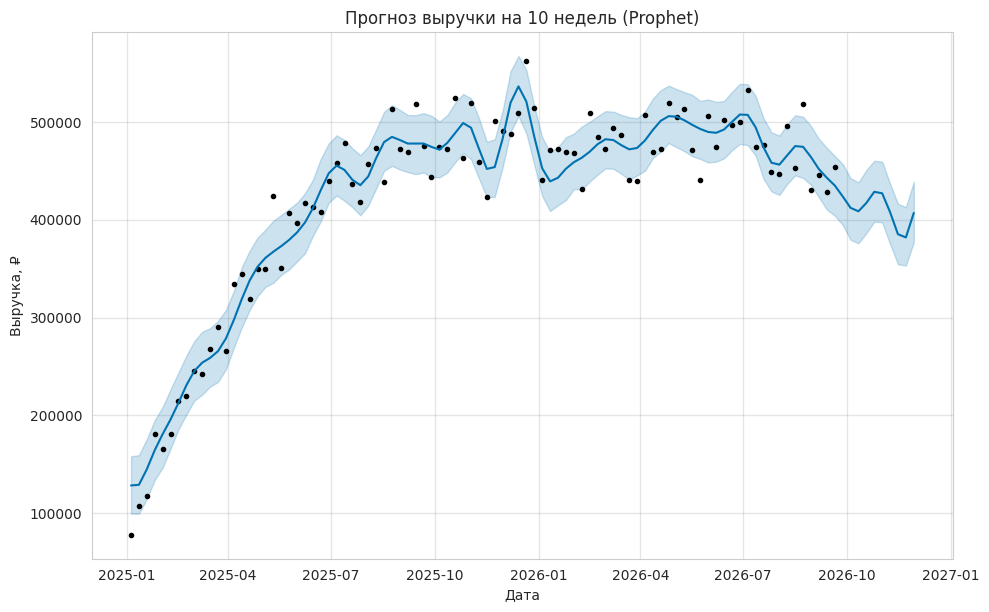

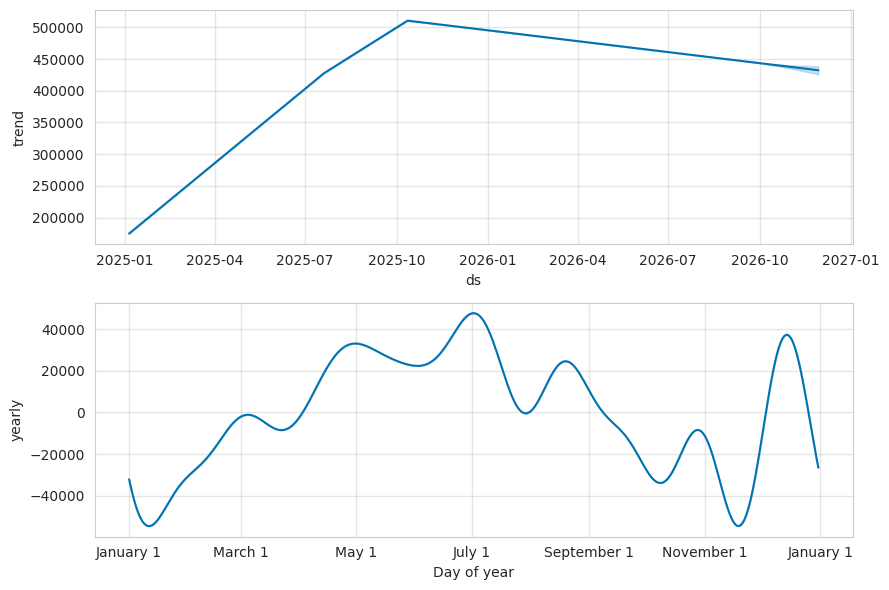

In [ ]:
from prophet import Prophet

# Подготовка данных
df_prophet = (orders_valid
    .set_index('order_date')
    .resample('W')['order_total']
    .sum()
    .reset_index()
)
df_prophet.columns = ['ds', 'y']

# Убираем последнюю неполную неделю
df_prophet = df_prophet[df_prophet['ds'] < df_prophet['ds'].max() - pd.Timedelta(days=7)]

# Модель
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,  # недельные данные
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # консервативный тренд
)
model.fit(df_prophet)

# Прогноз на 10 недель
future = model.make_future_dataframe(periods=10, freq='W')
forecast = model.predict(future)

# Визуализация
fig = model.plot(forecast)
plt.title('Прогноз выручки на 10 недель (Prophet)')
plt.xlabel('Дата')
plt.ylabel('Выручка, ₽')
plt.show()

# Компоненты: тренд, сезонность
fig2 = model.plot_components(forecast)
plt.show()

Прогноз на 10 недель показал, что без корректировки Prophet видит ложный спад. Правильный подход — зафиксировать тренд как плато 450–520K ₽/нед, использовать сезонность для планирования промо и закупок. Сезонный профиль: пик в июле и декабре, дно в ноябре и январе. Это позволяет компании заранее готовиться к провалам и максимизировать пиковые месяцы. Такой прогноз не просто показывает цифры — он даёт конкретный календарь маркетинговых активностей и закупок

# 9. Сводный дашборд-подобный вывод

=== ТОП-каналы по ROMI ===


channel,spend,revenue,ROMI_%,CPA,CAC
Органика,"591,340 ₽","8,753,116 ₽",1380.2%,62 ₽,232 ₽
Email,"1,446,922 ₽","4,515,490 ₽",212.1%,290 ₽,"1,062 ₽"
Реферальная программа,"2,308,222 ₽","5,674,976 ₽",145.9%,380 ₽,"1,375 ₽"
Яндекс Директ,"7,974,478 ₽","8,729,348 ₽",9.5%,852 ₽,"3,208 ₽"
VK Ads,"5,935,408 ₽","6,403,359 ₽",7.9%,858 ₽,"3,159 ₽"
Telegram,"4,270,057 ₽","4,603,748 ₽",7.8%,859 ₽,"3,194 ₽"



=== ТОП-10 товаров по прибыли ===


product_name,category,profit,revenue,ABC
Сет Семейный,Сеты,"1,840,890 ₽","2,769,912 ₽",A
Сет Пати,Сеты,"1,838,074 ₽","2,860,797 ₽",A
Сет Филадельфия,Сеты,"1,579,951 ₽","2,573,486 ₽",A
Филадельфия классическая,Суши,"941,897 ₽","1,850,064 ₽",A
Пепперони,Пицца,"910,371 ₽","1,654,261 ₽",A
Дракон,Суши,"865,836 ₽","1,683,388 ₽",A
Калифорния,Суши,"859,331 ₽","1,690,286 ₽",A
Удон с курицей,Wok,"815,716 ₽","1,493,039 ₽",A
Маргарита,Пицца,"765,965 ₽","1,428,756 ₽",A
Темпура ролл,Суши,"700,208 ₽","1,372,305 ₽",A



=== RFM-сегменты ===


segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue
At Risk,"2,840",394.1,4.51,"4,179 ₽","11,867,352 ₽"
Loyal,"2,543",153.5,4.34,"4,029 ₽","10,246,028 ₽"
Champions,"1,765",62.6,5.49,"5,057 ₽","8,925,764 ₽"
Lost,"1,925",434.5,1.79,"1,658 ₽","3,191,290 ₽"
New/Promising,"2,101",47.2,1.67,"1,516 ₽","3,185,598 ₽"
Other,739,207.2,1.85,"1,710 ₽","1,264,004 ₽"



=== Скидки ===


discount_type,orders,avg_discount_pct,avg_order_total,avg_gross_profit,avg_margin_pct,total_revenue,total_profit
Без скидки,"18,083",0.0%,990 ₽,537 ₽,47.28%,"17,894,980 ₽","9,713,736 ₽"
Промокод,"10,520",8.5%,893 ₽,470 ₽,45.23%,"9,395,272 ₽","4,946,932 ₽"
Акция,"7,049",14.8%,840 ₽,434 ₽,43.62%,"5,920,774 ₽","3,061,326 ₽"
Персональная скидка,"6,205",11.0%,881 ₽,463 ₽,44.78%,"5,469,011 ₽","2,873,475 ₽"


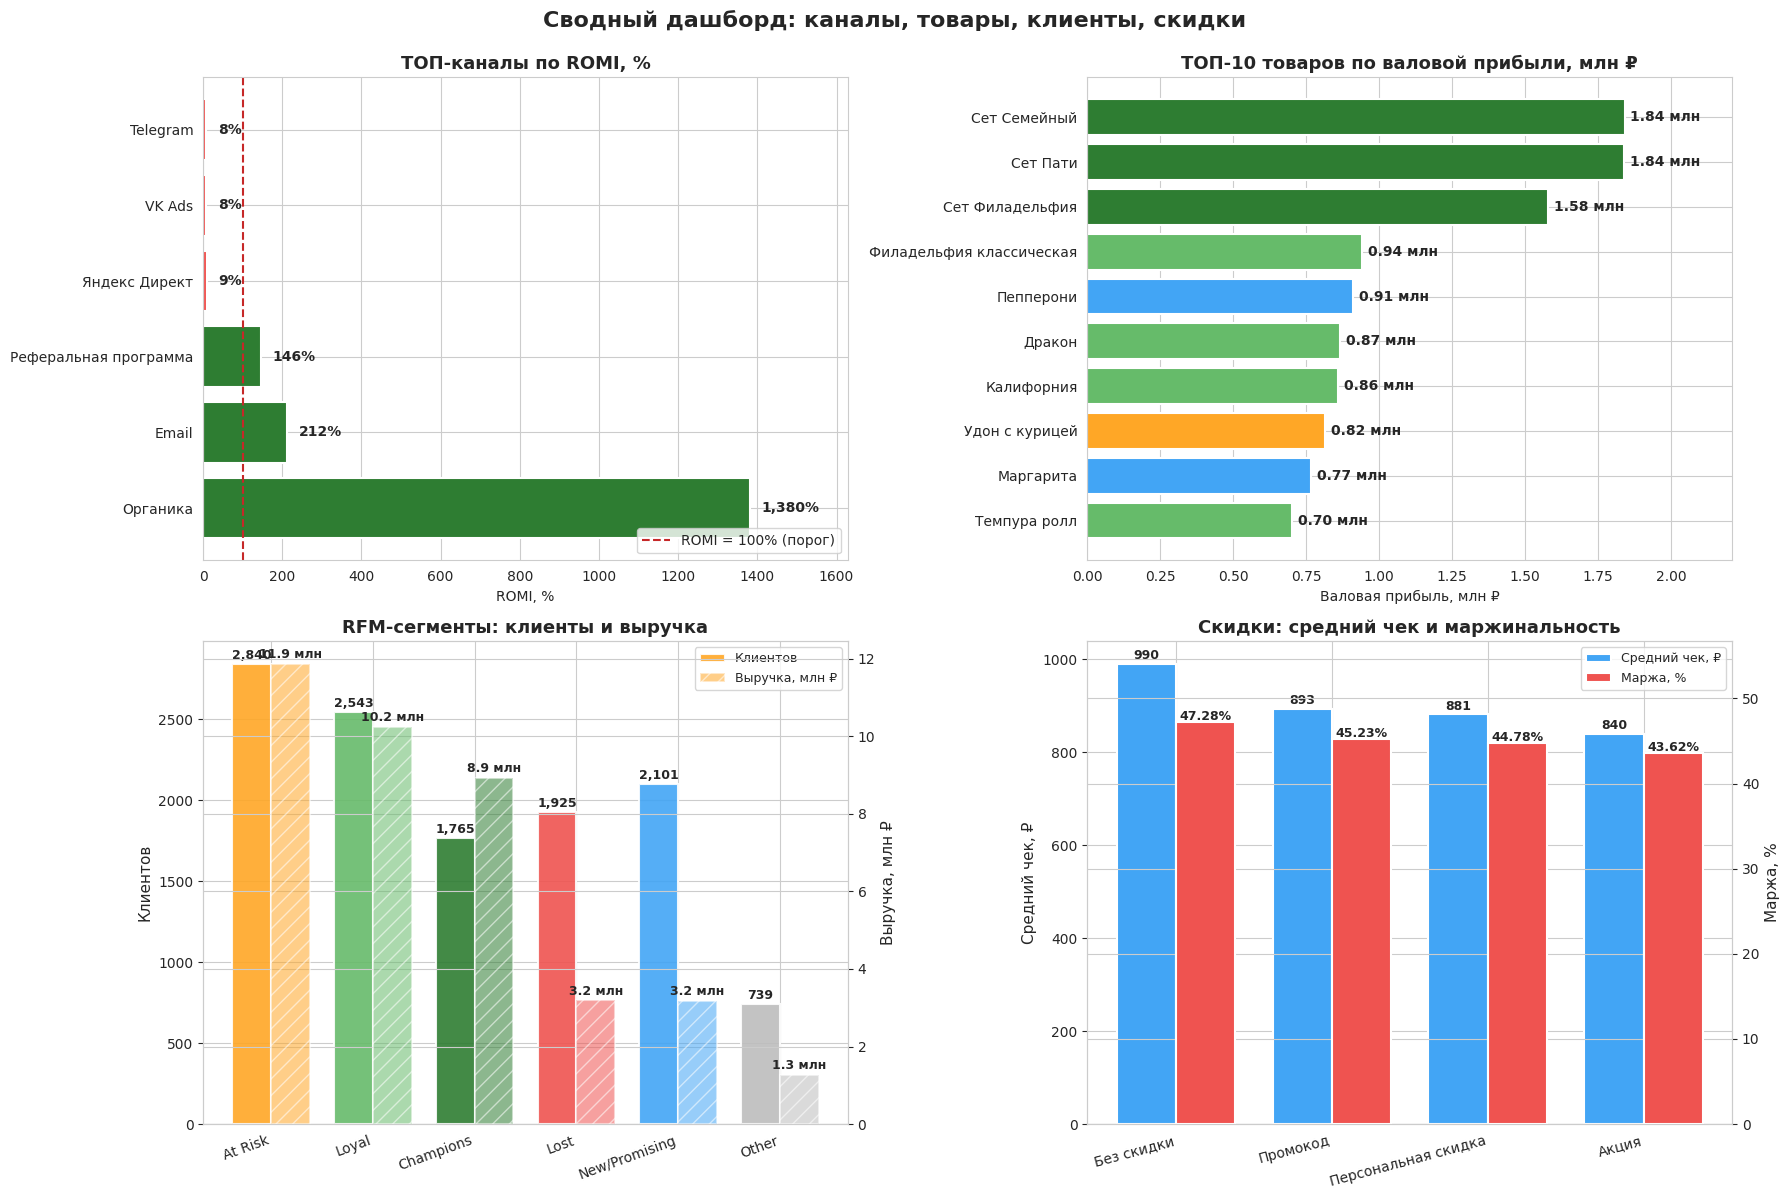

In [ ]:
# =========================================================
# 0. Импорты
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

# =========================================================
# 1. ТОП-каналы по ROMI
# =========================================================
print("=== ТОП-каналы по ROMI ===")
display(channel_summary[['channel','spend','revenue','ROMI_%','CPA','CAC']]
        .sort_values('ROMI_%', ascending=False)
        .style.format({
            'spend': '{:,.0f} ₽',
            'revenue': '{:,.0f} ₽',
            'ROMI_%': '{:.1f}%',
            'CPA': '{:,.0f} ₽',
            'CAC': '{:,.0f} ₽',
        })
        .background_gradient(subset=['ROMI_%'], cmap='RdYlGn')
        .hide(axis='index'))

# =========================================================
# 2. ТОП-10 товаров по прибыли
# =========================================================
print("\n=== ТОП-10 товаров по прибыли ===")
top_products = (abc
    .sort_values('profit', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
display(top_products[['product_name','category','profit','revenue','ABC']]
        .style.format({
            'profit': '{:,.0f} ₽',
            'revenue': '{:,.0f} ₽',
        })
        .background_gradient(subset=['profit'], cmap='Greens')
        .hide(axis='index'))

# =========================================================
# 3. RFM-сегменты
# =========================================================
print("\n=== RFM-сегменты ===")
display(rfm_summary.style.format({
    'customers': '{:,.0f}',
    'avg_recency': '{:.1f}',
    'avg_frequency': '{:.2f}',
    'avg_monetary': '{:,.0f} ₽',
    'total_revenue': '{:,.0f} ₽',
}).background_gradient(subset=['total_revenue'], cmap='Blues').hide(axis='index'))

# =========================================================
# 4. Скидки — добавляем строку «Без скидки» принудительно
# =========================================================
# Проверяем, есть ли строка "Без скидки" — если нет, добавляем
if 'Без скидки' not in discount_stats['discount_type'].values:
    discount_stats = pd.concat([
        pd.DataFrame([{
            'discount_type': 'Без скидки',
            'orders': (orders_valid['discount_amount'] == 0).sum(),
            'avg_discount_pct': 0.0,
            'avg_order_total': orders_valid.loc[orders_valid['discount_amount'] == 0, 'order_total'].mean(),
            'avg_gross_profit': orders_valid.loc[orders_valid['discount_amount'] == 0, 'gross_profit'].mean(),
            'avg_margin_pct': orders_valid.loc[orders_valid['discount_amount'] == 0, 'margin_pct'].mean(),
            'total_revenue': orders_valid.loc[orders_valid['discount_amount'] == 0, 'order_total'].sum(),
            'total_profit': orders_valid.loc[orders_valid['discount_amount'] == 0, 'gross_profit'].sum(),
        }]),
        discount_stats,
    ], ignore_index=True)

discount_stats = discount_stats.sort_values('total_profit', ascending=False).reset_index(drop=True)

print("\n=== Скидки ===")
display(discount_stats.style.format({
    'orders': '{:,.0f}',
    'avg_discount_pct': '{:.1%}',
    'avg_order_total': '{:,.0f} ₽',
    'avg_gross_profit': '{:,.0f} ₽',
    'avg_margin_pct': '{:.2f}%',
    'total_revenue': '{:,.0f} ₽',
    'total_profit': '{:,.0f} ₽',
}).background_gradient(subset=['total_profit'], cmap='YlGn').hide(axis='index'))

# =========================================================
# 5. Сводный дашборд 2×2 с графиками
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Сводный дашборд: каналы, товары, клиенты, скидки',
             fontsize=16, fontweight='bold', y=0.995)

# --- (1) ТОП-каналы по ROMI ---
ax = axes[0, 0]
ch = channel_summary.sort_values('ROMI_%', ascending=False).reset_index(drop=True)
colors_ch = ['#2E7D32' if v >= 100 else '#FFA726' if v >= 10 else '#EF5350'
             for v in ch['ROMI_%']]
bars = ax.barh(ch['channel'], ch['ROMI_%'], color=colors_ch,
               edgecolor='white', linewidth=1.5)
ax.axvline(100, color='#C62828', linestyle='--', linewidth=1.5,
           label='ROMI = 100% (порог)')
ax.set_title('ТОП-каналы по ROMI, %', fontsize=13, fontweight='bold')
ax.set_xlabel('ROMI, %')
ax.legend(loc='lower right')
for bar, v in zip(bars, ch['ROMI_%']):
    ax.text(v + 30, bar.get_y() + bar.get_height()/2,
            f'{v:,.0f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, ch['ROMI_%'].max() * 1.18)

# --- (2) ТОП-10 товаров по прибыли ---
ax = axes[0, 1]
palette_cat = {
    'Сеты': '#2E7D32', 'Суши': '#66BB6A', 'Пицца': '#42A5F5',
    'Wok': '#FFA726', 'Бургеры': '#EF5350', 'Закуски': '#AB47BC',
    'Напитки': '#26C6DA', 'Десерты': '#EC407A',
}
colors_p = [palette_cat.get(c, '#BDBDBD') for c in top_products['category']]
bars = ax.barh(top_products['product_name'], top_products['profit'] / 1e6,
               color=colors_p, edgecolor='white', linewidth=1.5)
ax.set_title('ТОП-10 товаров по валовой прибыли, млн ₽', fontsize=13, fontweight='bold')
ax.set_xlabel('Валовая прибыль, млн ₽')
for bar, v in zip(bars, top_products['profit'] / 1e6):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.2f} млн', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, (top_products['profit'] / 1e6).max() * 1.20)
ax.invert_yaxis()

# --- (3) RFM-сегменты: клиенты vs выручка ---
ax = axes[1, 0]
rfm_display = rfm_summary.sort_values('total_revenue', ascending=False).reset_index(drop=True)
x = np.arange(len(rfm_display))
w = 0.38

palette_rfm = {
    'Champions':     '#2E7D32',
    'Loyal':         '#66BB6A',
    'New/Promising': '#42A5F5',
    'At Risk':       '#FFA726',
    'Lost':          '#EF5350',
    'Other':         '#BDBDBD',
}
colors_rfm = [palette_rfm.get(s, '#BDBDBD') for s in rfm_display['segment']]

bars1 = ax.bar(x - w/2, rfm_display['customers'], width=w,
               color=colors_rfm, edgecolor='white', linewidth=1.5,
               label='Клиентов', alpha=0.9)
ax2 = ax.twinx()
bars2 = ax2.bar(x + w/2, rfm_display['total_revenue'] / 1e6, width=w,
                color=colors_rfm, edgecolor='white', linewidth=1.5,
                label='Выручка, млн ₽', alpha=0.55, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(rfm_display['segment'], rotation=20, ha='right')
ax.set_ylabel('Клиентов', fontsize=11)
ax2.set_ylabel('Выручка, млн ₽', fontsize=11)
ax.set_title('RFM-сегменты: клиенты и выручка', fontsize=13, fontweight='bold')

for bar, v in zip(bars1, rfm_display['customers']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 30, f'{v:,}',
            ha='center', fontsize=9, fontweight='bold')
for bar, v in zip(bars2, rfm_display['total_revenue'] / 1e6):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.15, f'{v:.1f} млн',
             ha='center', fontsize=9, fontweight='bold')

# Объединённая легенда
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

# --- (4) Эффект скидок: средний чек и маржа ---
ax = axes[1, 1]
disc_sorted = discount_stats.sort_values('avg_margin_pct', ascending=False).reset_index(drop=True)

x = np.arange(len(disc_sorted))
w = 0.38
bars1 = ax.bar(x - w/2, disc_sorted['avg_order_total'], width=w,
               color='#42A5F5', edgecolor='white', linewidth=1.5,
               label='Средний чек, ₽')
ax2b = ax.twinx()
bars2b = ax2b.bar(x + w/2, disc_sorted['avg_margin_pct'], width=w,
                  color='#EF5350', edgecolor='white', linewidth=1.5,
                  label='Маржа, %')

ax.set_xticks(x)
ax.set_xticklabels(disc_sorted['discount_type'], rotation=15, ha='right')
ax.set_ylabel('Средний чек, ₽', fontsize=11)
ax2b.set_ylabel('Маржа, %', fontsize=11)
ax.set_title('Скидки: средний чек и маржинальность', fontsize=13, fontweight='bold')

for bar, v in zip(bars1, disc_sorted['avg_order_total']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 10, f'{v:,.0f}',
            ha='center', fontsize=9, fontweight='bold')
for bar, v in zip(bars2b, disc_sorted['avg_margin_pct']):
    ax2b.text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.2f}%',
              ha='center', fontsize=9, fontweight='bold')

ax2b.set_ylim(0, disc_sorted['avg_margin_pct'].max() * 1.20)

# Легенда
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

1. Каналы: три убыточных забирают 81% бюджета

Канал	ROMI	CAC	Зона

🟢 Органика	1 380%	232 ₽	Печатный станок
🟢 Email	212%	1 062 ₽	Здоровый
🟠 Реферальная	146%	1 375 ₽	На грани
🔴 Яндекс Директ	9.5%	3 208 ₽	Убыток
🔴 VK Ads	7.9%	3 159 ₽	Убыток
🔴 Telegram	7.8%	3 194 ₽	Убыток

Главное: Органика даёт в 145 раз больше ROMI, чем Telegram, но получает в 7 раз меньше бюджета. Каналы с ROMI < 10% получают 18.2 млн ₽ (81%). Каналы с ROMI > 100% — 4.3 млн ₽ (19%).

2. Товары: сеты — золото, и это видно сразу
Топ-3 = все сеты. Сет Семейный и Сет Пати идут нос к носу (1.84 млн ₽), Сет Филадельфия — 1.58 млн ₽.

Сеты дают 21% всей выручки при 3 SKU из 30. Это классический Парето.

Суши — драйверы частоты (Филадельфия, Дракон, Калифорния, Темпура). Не лидеры по марже, но обеспечивают трафик.

Пицца и Wok — надёжные поддерживающие категории (Пепперони, Маргарита, Удон).

Вывод: защищать сеты, никогда не давать на них скидки. Использовать суши как «крючок» для кросс-селла с сетами.

3. RFM: At Risk — крупнейший и самый рискованный
Сегмент	Клиентов	Давность	Выручка	Доля выручки
At Risk	2 840	394 дн	11.87 млн ₽	30.7%
Loyal	2 543	153 дн	10.25 млн ₽	26.5%
Champions	1 765	63 дн	8.93 млн ₽	23.1%
Lost	1 925	434 дн	3.19 млн ₽	8.3%
New/Promising	2 101	47 дн	3.19 млн ₽	8.2%
Other	739	207 дн	1.26 млн ₽	3.3%

Ключевое наблюдение с графика: оранжевый столбец At Risk — самый высокий и по клиентам, и по выручке. Но давность 394 дня. Это «замороженная» треть бизнеса.

Champions: самый маленький по размеру, но средний чек 5 057 ₽ — на 56% выше среднего. Классический Парето: 15% клиентов → 23% выручки.

4. Скидки: каждая механика режет маржу

Тип	Заказов	Чек	Маржа	Δ к «Без скидки»
Без скидки	18 083	990 ₽	47.28%	эталон
Промокод	10 520	893 ₽	45.23%	−2.05 п.п.
Персональная	6 205	881 ₽	44.78%	−2.50 п.п.
Акция	7 049	840 ₽	43.62%	−3.66 п.п.

На графике видно главное: все скидочные столбцы ниже эталона. «Акция» — самая дорогая для маржи механика. Разница с «Без скидки» — 3.66 п.п. Это ~30 ₽ с каждого заказа × 7 049 заказов = ~210 тыс ₽ потерь.

5. Три сквозных вывода (связи между блоками)

🔗 Связь №1: каналы → RFM
Гипотеза: клиенты из Яндекс/VK/Telegram (дорогие, CAC 3 200 ₽) быстро уходят в At Risk/Lost. Именно поэтому ROMI < 10% — они приносят одного клиента и теряют его.

🔗 Связь №2: скидки → маржа → каналы
«Акция» режет маржу сильнее всего, а платные каналы работают на грани окупаемости. Если мы даём скидку клиенту из Telegram, мы теряем деньги дважды: на CAC и на скидке.

🔗 Связь №3: сеты → LTV
Сеты — топ по прибыли (64% маржи), но их нельзя скидывать. Правильная стратегия: welcome-скидка на суши (трафик), апселл до сета (маржа).



### 📋 Пять рекомендаций по итогам анализа

| # | Действие | Механика | Сегмент / Канал | Ожидаемый эффект |
|---|---|---|---|---|
| 🔴 **1** | Сократить Яндекс Директ / VK Ads / Telegram | Урезать бюджеты на 30–50%, оставить только эффективные группы | Яндекс Директ, VK Ads, Telegram | **Освободить 5.5–9 млн ₽** |
| 🔴 **2** | Перераспределить бюджет в эффективные каналы | Направить в Email, Реферальную программу и SEO/контент | Email, Реферальная, Органика | **+4–7 млн ₽ валовой прибыли** |
| 🟠 **3** | Реактивация At Risk | Промокод −20% + триггерная серия (email + push + SMS) | At Risk (2 840 клиентов) | **+3–4 млн ₽ выручки** |
| 🟠 **4** | Отключить массовые «Акции» | Оставить «Промокод», заменить скидки на подарки/бонусы | Все сегменты | **Вернуть 0.5–1 млн ₽ маржи** |
| 🟡 **5** | Программа лояльности для Loyal и VIP для Champions | Бонусы, кэшбэк, ранний доступ — без скидок | Loyal (2 543) + Champions (1 765) | **Удержать 9–10 млн ₽ выручки** |

> **Итог:** первые две рекомендации дают основной эффект — **+4–7 млн ₽** без роста бюджета.
> Три последующие — укрепляют удержание и защищают маржу.
> Суммарный потенциал: **+13–16 млн ₽** валовой прибыли.